In [17]:
# =========================================================
# Prequential GP evaluation — CORRECTED
#
# Changes vs original:
#   1. Pointwise scoring uses predict_y (latent var + noise),
#      instead of predict_f. Means are unchanged → MAE/RMSE
#      are identical; only variance-based scores change.
#   2. Joint scoring keeps predict_f(full_cov=True) for the
#      latent covariance, then adds sigma2_eps * I to the
#      DIAGONAL by hand (predict_y(full_cov=True) is buggy in
#      GPflow — it adds noise to every element, not just the
#      diagonal; see GPflow issue #1461). This both corrects
#      the score and regularises the near-singular matrices
#      that caused the multiple-kernel blow-ups.
#   3. _preq_multivariate_log_score now REPORTS when it falls back
#      to the marginal score (Sigma not PD) instead of doing
#      it silently. A 'fallback' flag is propagated.
#   4. Aggregation expanded:
#        - per-sim then across-sim summaries
#        - mean, median, sd, var, 95% percentile interval,
#          95% CI on the mean
#        - aggregate SUM (total prequential log score) per sim,
#          then summarised across sims (mean & median of totals)
#        - everything computed for ALL runs and for
#          SUCCESSFULLY-OPTIMISED runs separately
# =========================================================

import numpy as np
import pandas as pd
import tensorflow as tf
import gpflow
import time
import warnings

warnings.filterwarnings("ignore", category=UserWarning)


# =========================================================
# Brownian motion kernel: K(t,t') = sigma2 * min(t,t')
# =========================================================
class _preq_BrownianMotion(gpflow.kernels.Kernel):
    def __init__(self, variance=1.0):
        super().__init__()
        self.variance = gpflow.Parameter(variance, transform=gpflow.utilities.positive())

    def K(self, X, X2=None):
        if X2 is None:
            X2 = X
        t1 = X[:, 0:1]
        t2 = X2[:, 0:1]
        return self.variance * tf.minimum(t1, tf.transpose(t2))

    def K_diag(self, X):
        return self.variance * tf.reshape(X[:, 0], (-1,))


# =========================================================
# Exchangeable kernel
# Cov(y_i(t), y_j(t')) = k_mu(t,t') + I(i==j) * k_x(t,t')
# base_kernel_mu = None  →  independent (no shared mean)
# unit_kernels_x = [k]   →  shared unit kernel across units
# unit_kernels_x = [k0, k1, ...] → per-unit kernels
# =========================================================
class _preq_ExchangeableKernel(gpflow.kernels.Kernel):
    def __init__(self, base_kernel_mu, unit_kernels_x, task_dim=0, time_dim=1):
        super().__init__()
        self.base_kernel_mu = base_kernel_mu
        self.unit_kernels_x = unit_kernels_x
        self.task_dim = task_dim
        self.time_dim = time_dim

    def K(self, X, X2=None):
        if X2 is None:
            X2 = X
        T1 = X[:,  self.time_dim:self.time_dim + 1]
        T2 = X2[:, self.time_dim:self.time_dim + 1]
        U1 = X[:,  self.task_dim]
        U2 = X2[:, self.task_dim]

        n1 = tf.shape(X)[0]
        n2 = tf.shape(X2)[0]
        K_total = tf.zeros((n1, n2), dtype=X.dtype)

        if self.base_kernel_mu is not None:
            K_total = K_total + self.base_kernel_mu.K(T1, T2)

        num_kernels = len(self.unit_kernels_x)
        for uid, k_xi in enumerate(self.unit_kernels_x):
            if num_kernels == 1:
                task_match = tf.cast(tf.equal(U1[:, None], U2[None, :]), dtype=X.dtype)
            else:
                mask_i = tf.cast(tf.equal(U1, float(uid)), dtype=X.dtype)
                mask_j = tf.cast(tf.equal(U2, float(uid)), dtype=X.dtype)
                task_match = tf.linalg.matmul(mask_i[:, None], mask_j[None, :])
            K_total = K_total + task_match * k_xi.K(T1, T2)

        return K_total

    def K_diag(self, X):
        T = X[:, self.time_dim:self.time_dim + 1]
        U = X[:, self.task_dim]

        K_diag_total = tf.zeros(tf.shape(X)[0:1], dtype=X.dtype)

        if self.base_kernel_mu is not None:
            K_diag_total = K_diag_total + self.base_kernel_mu.K_diag(T)

        num_kernels = len(self.unit_kernels_x)
        for uid, k_xi in enumerate(self.unit_kernels_x):
            if num_kernels == 1:
                K_diag_total = K_diag_total + k_xi.K_diag(T)
            else:
                mask_i = tf.cast(tf.equal(U, float(uid)), dtype=T.dtype)
                K_diag_total = K_diag_total + mask_i * k_xi.K_diag(T)

        return K_diag_total


# =========================================================
# Model specs: 4 models per kernel
# =========================================================
def _preq_get_model_specs(kernel_type):
    return [
        {"model_name": f"exch_shared_{kernel_type}",   "exchangeable": True,  "multiple": False},
        {"model_name": f"exch_multiple_{kernel_type}", "exchangeable": True,  "multiple": True},
        {"model_name": f"indep_shared_{kernel_type}",  "exchangeable": False, "multiple": False},
        {"model_name": f"indep_multiple_{kernel_type}","exchangeable": False, "multiple": True},
    ]


# =========================================================
# Unified fit function
# =========================================================
def _preq_fit_gp(df,
           exchangeable=True,
           multiple=False,
           kernel_type="rbf",
           init_variance=1.0,
           init_lengthscale=15.0,
           init_noise=0.05,
           maxiter=200,
           verbose=False):

    X = df[["unit_id", "time"]].to_numpy(dtype=np.float64)
    Y = df[["y"]].to_numpy(dtype=np.float64)
    num_units = int(len(np.unique(X[:, 0])))

    def make_kernel():
        if kernel_type == "rbf":
            return gpflow.kernels.RBF(variance=init_variance, lengthscales=init_lengthscale)
        elif kernel_type == "brownian":
            return _preq_BrownianMotion(variance=init_variance)
        else:
            raise ValueError("kernel_type must be 'rbf' or 'brownian'")

    base_kernel_mu = make_kernel() if exchangeable else None
    num_x_kernels  = num_units if multiple else 1
    unit_kernels_x = [make_kernel() for _ in range(num_x_kernels)]

    kernel = _preq_ExchangeableKernel(
        base_kernel_mu=base_kernel_mu,
        unit_kernels_x=unit_kernels_x,
        task_dim=0, time_dim=1,
    )

    likelihood = gpflow.likelihoods.Gaussian(variance=init_noise)
    model      = gpflow.models.GPR(data=(X, Y), kernel=kernel, likelihood=likelihood)

    opt      = gpflow.optimizers.Scipy()
    opt_logs = opt.minimize(
        model.training_loss,
        variables=model.trainable_variables,
        options={"maxiter": maxiter},
        compile=False,
    )

    if verbose:
        label = (f"{'Exchangeable' if exchangeable else 'Independent'} | "
                 f"{'Multiple' if multiple else 'Shared'} | {kernel_type.upper()}")
        print(f"  [{label}] success={opt_logs.success}")

    return model, opt_logs


# =========================================================
# Pointwise predict — CORRECTED to predict_y
# predict_y returns mean (== predict_f mean) and
# var = var_f + sigma2_eps  (marginal, noise included).
# =========================================================
def _preq_predict_gp(model, df_test):
    Xnew = df_test[["unit_id", "time"]].to_numpy(dtype=np.float64)
    mean, var = model.predict_y(Xnew)          # <-- was predict_f
    out = df_test.copy()
    out["pred_mean"]  = mean.numpy().flatten()
    out["pred_var"]   = var.numpy().flatten()
    out["pred_sd"]    = np.sqrt(np.maximum(out["pred_var"], 1e-12))
    out["pred_lo_95"] = out["pred_mean"] - 1.96 * out["pred_sd"]
    out["pred_hi_95"] = out["pred_mean"] + 1.96 * out["pred_sd"]
    return out


# =========================================================
# Hyperparameter extraction (unchanged)
# =========================================================
def _preq_extract_hyperparams(model, simulation, model_name, origin,
                        exchangeable, multiple, kernel_type,
                        optim_success, fit_time):
    kernel = model.kernel
    noise  = float(np.asarray(model.likelihood.variance.numpy()).squeeze())

    if exchangeable:
        sigma2_mu = float(kernel.base_kernel_mu.variance.numpy())
        ls_mu     = (float(np.asarray(kernel.base_kernel_mu.lengthscales.numpy()).squeeze())
                     if kernel_type == "rbf" else np.nan)
    else:
        sigma2_mu = np.nan
        ls_mu     = np.nan

    rows = []
    for uid, k_xi in enumerate(kernel.unit_kernels_x):
        sigma2_xi = float(k_xi.variance.numpy())
        ls_xi     = (float(np.asarray(k_xi.lengthscales.numpy()).squeeze())
                     if kernel_type == "rbf" else np.nan)
        icc_i = (sigma2_mu / (sigma2_mu + sigma2_xi)
                 if (exchangeable and not np.isnan(sigma2_mu) and (sigma2_mu + sigma2_xi) > 0)
                 else np.nan)
        rows.append({
            "simulation": simulation, "model_name": model_name, "origin": origin,
            "unit_kernel_id": uid if multiple else "shared",
            "sigma2_mu": sigma2_mu, "ls_mu": ls_mu,
            "sigma2_x": sigma2_xi, "ls_x": ls_xi, "icc": icc_i, "noise": noise,
            "optim_success": int(optim_success), "fit_time": fit_time,
        })
    return rows


# =========================================================
# Pointwise scoring helpers
# =========================================================
def _preq_gaussian_log_score(y, mu, var):
    var = np.maximum(var, 1e-12)
    return 0.5 * np.log(2.0 * np.pi * var) + 0.5 * ((y - mu) ** 2) / var


def _preq_compute_pointwise_scores(df_pred):
    out = df_pred.copy()
    out["error"]     = out["y"] - out["pred_mean"]
    out["abs_error"] = np.abs(out["error"])
    out["sq_error"]  = out["error"] ** 2
    out["log_score"] = _preq_gaussian_log_score(out["y"].values, out["pred_mean"].values, out["pred_var"].values)
    return out


# =========================================================
# Multivariate log score — now returns (score, used_fallback)
# =========================================================
def _preq_multivariate_log_score(y_vec, mu_vec, Sigma):
    """
    Negative log density of MVN:
      0.5 * (n log(2π) + log det Σ + (y-μ)^T Σ^{-1} (y-μ))
    Returns (score, used_fallback). used_fallback=True means Σ was
    not positive-definite and the marginal score was used instead.
    """
    y     = np.asarray(y_vec).reshape(-1, 1)
    mu    = np.asarray(mu_vec).reshape(-1, 1)
    n     = y.shape[0]
    Sigma = np.asarray(Sigma, dtype=np.float64)

    # Positive-definiteness / conditioning test on the NATIVE matrix
    # (before any jitter), so the test reflects the matrix's true
    # conditioning rather than the jitter floor. We reject matrices that
    # are non-PD OR severely ill-conditioned: there Sigma^{-1} explodes and
    # the quadratic form blows up — the mechanism behind the multiple-kernel
    # blow-ups seen in the results. Eigenvalues give an unambiguous
    # condition number.
    COND_MAX = 1e10  # reject if lambda_max / lambda_min exceeds this
    use_fallback = False
    try:
        evals = np.linalg.eigvalsh(Sigma)          # symmetric -> real eigenvalues
        lmin, lmax = float(evals[0]), float(evals[-1])
        cond = (lmax / lmin) if lmin > 0 else np.inf
        if (not np.isfinite(lmin)) or (lmin <= 0) or (cond > COND_MAX):
            use_fallback = True
        else:
            # scale-aware jitter (tiny relative to the matrix) for the factorisation
            jitter = 1e-10 * max(lmax, 1.0)
            L = np.linalg.cholesky(Sigma + np.eye(n) * jitter)
    except np.linalg.LinAlgError:
        use_fallback = True

    if use_fallback:
        Sigma = Sigma + np.eye(n) * 1e-8  # stabilise the marginal fallback only
        diff     = y.flatten() - mu.flatten()
        marg_var = np.maximum(np.diag(Sigma), 1e-12)
        score = 0.5 * np.sum(np.log(2.0 * np.pi * marg_var) + (diff**2) / marg_var)
        return float(score), True

    # logdet = 2 * sum(log(diag(L)));  quad = ||L^{-1} (y-mu)||^2 via solve
    diff   = y - mu
    logdet = 2.0 * float(np.sum(np.log(np.diag(L))))
    z      = np.linalg.solve(L, diff)
    quad   = float((z.T @ z).item())
    score  = 0.5 * (n * np.log(2.0 * np.pi) + logdet + quad)
    return float(score), False


# =========================================================
# Joint score per time step — CORRECTED
# Uses latent full covariance from predict_f, then adds
# sigma2_eps * I to the diagonal (observation-level joint cov).
# =========================================================
def _preq_joint_score_per_timestep(model, test_df):
    noise = float(np.asarray(model.likelihood.variance.numpy()).squeeze())
    rows = []
    for t in sorted(test_df["time"].unique()):
        df_t = test_df[test_df["time"] == t].sort_values("unit_id")
        y_t  = df_t["y"].to_numpy(dtype=np.float64)
        Xnew = df_t[["unit_id", "time"]].to_numpy(dtype=np.float64)

        mean_t, cov_t = model.predict_f(Xnew, full_cov=True)   # latent, noise-free
        mu_t    = mean_t.numpy().flatten()
        Sigma_t = cov_t.numpy()[0, :, :]
        # add observation noise on the diagonal only (units conditionally
        # independent given the latent functions) -> covariance of y
        Sigma_t = Sigma_t + noise * np.eye(Sigma_t.shape[0])

        score_t, used_fallback = _preq_multivariate_log_score(y_t, mu_t, Sigma_t)
        rows.append({
            "time": t,
            "n_units": len(y_t),
            "joint_log_score": score_t,
            "fallback": int(used_fallback),
        })
    return rows


# =========================================================
# Optimisation success helper
# =========================================================
def _preq_scipy_result_success(res):
    if res is None:
        return False
    if hasattr(res, "success"):
        return bool(res.success)
    if isinstance(res, dict) and "success" in res:
        return bool(res["success"])
    return True


# =========================================================
# Tidy aggregation helpers
# =========================================================
def _preq__across_sim_block(series):
    """Summarise a per-simulation statistic across simulations."""
    s = pd.Series(series).dropna()
    n = int(s.size)
    mean = float(s.mean()) if n else np.nan
    sd   = float(s.std(ddof=1)) if n > 1 else np.nan
    se   = sd / np.sqrt(n) if (n > 1 and np.isfinite(sd)) else np.nan
    return {
        "n_sims":    n,
        "mean":      mean,
        "median":    float(s.median()) if n else np.nan,
        "sd":        sd,
        "var":       float(s.var(ddof=1)) if n > 1 else np.nan,
        "q2_5":      float(s.quantile(0.025)) if n else np.nan,
        "q97_5":     float(s.quantile(0.975)) if n else np.nan,
        "ci95_lo":   mean - 1.96 * se if np.isfinite(se) else np.nan,
        "ci95_hi":   mean + 1.96 * se if np.isfinite(se) else np.nan,
        "grand_sum": float(s.sum()) if n else np.nan,
    }


def _preq__per_sim_metric(d, metric, value_col):
    """One value per (simulation, model_name) for a given metric."""
    grp = d.groupby(["simulation", "model_name"])[value_col]
    if metric == "rmse":                      # value_col = sq_error
        out = np.sqrt(grp.mean())
    elif metric == "sum":                     # total / additive score
        out = grp.sum()
    else:                                     # mean of the column
        out = grp.mean()
    return out.reset_index(name="v")


def _preq_summarise_metric(long_df, value_col, metric, score_type, include_total):
    """
    Build tidy summary rows for one metric, across every combination of
    horizon_scope (full / first_day) x run_set (all / successful) x
    agg (per_sim_mean / per_sim_total*).  *totals only when include_total.
    """
    rows = []
    for scope in ("full", "first_day"):
        d_scope = long_df if scope == "full" else long_df[long_df["horizon_step"] == 1]
        for run_set in ("all", "successful"):
            d = d_scope if run_set == "all" else d_scope[d_scope["optim_success"] == 1]
            if d.empty:
                continue

            agg_specs = [("per_sim_mean", metric)]
            if include_total:
                agg_specs.append(("per_sim_total", "sum"))

            for agg_name, per_sim_metric in agg_specs:
                ps = _preq__per_sim_metric(d, per_sim_metric, value_col)
                for model, sub in ps.groupby("model_name"):
                    rows.append({
                        "score_type":    score_type,
                        "metric":        metric,
                        "horizon_scope": scope,
                        "run_set":       run_set,
                        "aggregation": agg_name,
                        "model_name":    model,
                        **_preq__across_sim_block(sub["v"]),
                    })
    return rows


def _preq_build_summarised_scores(predictions_all, joint_all):
    """
    Single tidy table summarising all scores across simulations.
    Columns: score_type, metric, horizon_scope, run_set, agg, model_name,
             n_sims, mean, median, sd, var, q2_5, q97_5, ci95_lo, ci95_hi, grand_sum
    """
    rows = []

    # joint log score (additive -> totals meaningful)
    if not joint_all.empty:
        rows += _preq_summarise_metric(joint_all, "joint_log_score",
                                 "joint_log_score", "joint", include_total=True)

    # pointwise scores
    if not predictions_all.empty:
        # log score: mean and total
        rows += _preq_summarise_metric(predictions_all, "log_score",
                                 "log_score", "pointwise", include_total=True)
        # mae: mean of abs_error
        rows += _preq_summarise_metric(predictions_all, "abs_error",
                                 "mae", "pointwise", include_total=False)
        # rmse: sqrt(mean(sq_error))
        rows += _preq_summarise_metric(predictions_all, "sq_error",
                                 "rmse", "pointwise", include_total=False)

    cols = ["score_type", "metric", "horizon_scope", "run_set", "aggregation", "model_name",
            "n_sims", "mean", "median", "sd", "var",
            "q2_5", "q97_5", "ci95_lo", "ci95_hi", "grand_sum"]
    df = pd.DataFrame(rows)
    return df[cols] if not df.empty else pd.DataFrame(columns=cols)


def _preq_build_success_rate(optim_all, joint_all):
    """Optimisation success summarised across all simulations, per model."""
    if optim_all.empty:
        return pd.DataFrame()

    pooled = (optim_all.groupby("model_name", as_index=False)
              .agg(n_runs=("optim_success", "size"),
                   n_success=("optim_success", "sum"))
              .assign(success_rate=lambda d: d["n_success"] / d["n_runs"],
                      success_pct=lambda d: 100.0 * d["n_success"] / d["n_runs"]))

    per_sim = (optim_all.groupby(["simulation", "model_name"], as_index=False)
               .agg(rate=("optim_success", "mean")))
    per_sim_summ = (per_sim.groupby("model_name", as_index=False)
                    .agg(mean_success_rate_per_sim=("rate", "mean"),
                         sd_success_rate_per_sim=("rate", "std")))

    out = pooled.merge(per_sim_summ, on="model_name", how="left")

    # scoring-health diagnostic: how often the joint covariance fell back
    if not joint_all.empty and "fallback" in joint_all.columns:
        fb = (joint_all.groupby("model_name", as_index=False)
              .agg(n_joint_timesteps=("fallback", "size"),
                   n_fallback=("fallback", "sum"))
              .assign(fallback_pct=lambda d: 100.0 * d["n_fallback"] / d["n_joint_timesteps"]))
        out = out.merge(fb, on="model_name", how="left")

    return out.sort_values("model_name").reset_index(drop=True)


# =========================================================
# Prequential: one simulation   (step == horizon, non-overlapping)
# =========================================================
def _preq_prequential_one_simulation(df, simulation_name="sim", kernel_type="rbf",
                               train_end_start=50, horizon=7,
                               maxiter=200, verbose=True):
    model_specs = _preq_get_model_specs(kernel_type)
    df       = df.copy().sort_values(["unit_id", "time"]).reset_index(drop=True)
    max_time = df["time"].max()

    # step is fixed to horizon -> non-overlapping windows, each point scored once
    step = horizon
    origins   = []
    train_end = train_end_start
    while train_end + horizon <= max_time:
        origins.append(train_end)
        train_end += step

    if verbose:
        print(f"  Simulation {simulation_name} | kernel={kernel_type} | "
              f"horizon={horizon} | origins={origins}")

    prediction_rows, joint_rows = [], []
    hyperparam_rows, timing_rows, optim_rows = [], [], []

    for spec in model_specs:
        model_name   = spec["model_name"]
        exchangeable = spec["exchangeable"]
        multiple     = spec["multiple"]
        if verbose:
            print(f"    Model: {model_name}")

        for origin in origins:
            train_df = df[df["time"] <= origin].copy()
            test_df  = df[(df["time"] > origin) & (df["time"] <= origin + horizon)].copy()
            if test_df.empty:
                continue
            try:
                t0 = time.perf_counter()
                model, opt_res = _preq_fit_gp(train_df, exchangeable=exchangeable,
                                        multiple=multiple, kernel_type=kernel_type,
                                        maxiter=maxiter, verbose=False)
                fit_time      = time.perf_counter() - t0
                optim_success = _preq_scipy_result_success(opt_res)

                # pointwise
                pred_df = _preq_predict_gp(model, test_df)
                pred_df = _preq_compute_pointwise_scores(pred_df)
                pred_df["simulation"]    = simulation_name
                pred_df["model_name"]    = model_name
                pred_df["origin"]        = origin
                pred_df["horizon_step"]  = pred_df["time"] - origin
                pred_df["first_day"]     = (pred_df["horizon_step"] == 1).astype(int)
                pred_df["optim_success"] = int(optim_success)
                pred_df["fit_time"]      = fit_time
                prediction_rows.append(pred_df)

                # joint (per timestep across units)
                for ts in _preq_joint_score_per_timestep(model, test_df):
                    hstep = ts["time"] - origin
                    joint_rows.append({
                        "simulation": simulation_name, "model_name": model_name,
                        "origin": origin, "time": ts["time"], "horizon_step": hstep,
                        "first_day": int(hstep == 1), "n_units": ts["n_units"],
                        "joint_log_score": ts["joint_log_score"], "fallback": ts["fallback"],
                        "optim_success": int(optim_success), "fit_time": fit_time,
                    })

                # hyperparameters
                hyperparam_rows.extend(_preq_extract_hyperparams(
                    model, simulation_name, model_name, origin,
                    exchangeable=exchangeable, multiple=multiple,
                    kernel_type=kernel_type, optim_success=optim_success,
                    fit_time=fit_time))

                timing_rows.append({"simulation": simulation_name, "model_name": model_name,
                                    "origin": origin, "fit_time": fit_time})
                optim_rows.append({"simulation": simulation_name, "model_name": model_name,
                                   "origin": origin, "optim_success": int(optim_success),
                                   "fit_time": fit_time})

            except Exception as e:
                if verbose:
                    print(f"      Failed at origin {origin}: {e}")
                timing_rows.append({"simulation": simulation_name, "model_name": model_name,
                                    "origin": origin, "fit_time": np.nan})
                optim_rows.append({"simulation": simulation_name, "model_name": model_name,
                                   "origin": origin, "optim_success": 0, "fit_time": np.nan})

    def _cat(lst, df_fallback=pd.DataFrame()):
        return pd.concat(lst, axis=0).reset_index(drop=True) if lst else df_fallback

    return (_cat(prediction_rows),
            pd.DataFrame(joint_rows),
            pd.DataFrame(hyperparam_rows),
            pd.DataFrame(timing_rows),
            pd.DataFrame(optim_rows))


# =========================================================
# Prequential: all simulations  ->  5 tidy outputs
# =========================================================
def prequential_all_simulations(all_simulations, kernel_type="rbf", scenario=None,
                                simulation_keys=None, train_end_start=50,
                                horizon=7, maxiter=200, verbose=True):
    """
    Returns a dict with five tidy tables (each becomes one Excel sheet):

      model_parameters  : fitted kernel hyperparameters per (sim, model, origin, unit)
      predictions       : predicted values per observation (+ truth, first_day, optim_success)
      individual_scores : per-observation scores + optim_success (+ first_day)
      summarised_scores : scores summarised across simulations (mean/median/sd/var/95%/total),
                          for full horizon AND first-day, ALL AND successful runs
      success_rate      : optimisation success summarised across all simulations, per model

    Also returns (in memory, not written by default):
      joint_individual  : raw per-timestep joint log scores (feed the joint summary)
      meta              : run metadata
    """
    if simulation_keys is None:
        simulation_keys = sorted(all_simulations.keys())

    all_pred, all_joint, all_hyper, all_time, all_optim = [], [], [], [], []
    total_start = time.perf_counter()

    for sim_key in simulation_keys:
        if verbose:
            print("=" * 70)
            print(f"Simulation: {sim_key} | kernel: {kernel_type}")
            print("=" * 70)
        df = all_simulations[sim_key].copy()
        if scenario is not None and "scenario" in df.columns:
            df = df[df["scenario"] == scenario].copy()

        preds, joint, hps, times, opts = _preq_prequential_one_simulation(
            df=df, simulation_name=sim_key, kernel_type=kernel_type,
            train_end_start=train_end_start, horizon=horizon,
            maxiter=maxiter, verbose=verbose)

        all_pred.append(preds); all_joint.append(joint); all_hyper.append(hps)
        all_time.append(times); all_optim.append(opts)

    total_elapsed = time.perf_counter() - total_start

    def _cat(lst):
        lst = [x for x in lst if x is not None and not x.empty]
        return pd.concat(lst, axis=0).reset_index(drop=True) if lst else pd.DataFrame()

    predictions_all = _cat(all_pred)
    joint_all       = _cat(all_joint)
    hyperparams_all = _cat(all_hyper)
    optim_all       = _cat(all_optim)

    # ── Sheet 1: model parameters (fitted hyperparameters) ──
    model_parameters = hyperparams_all

    # ── Sheet 2: predictions (predicted values only) ──
    pred_cols = ["simulation", "model_name", "origin", "unit_id", "time",
                 "horizon_step", "first_day",
                 "y", "true_x", "true_mu",
                 "pred_mean", "pred_var", "pred_sd", "pred_lo_95", "pred_hi_95",
                 "optim_success"]
    predictions = (predictions_all[[c for c in pred_cols if c in predictions_all.columns]]
                   if not predictions_all.empty else pd.DataFrame(columns=pred_cols))

    # ── Sheet 3: individual scores (per observation) + optim_success ──
    score_cols = ["simulation", "model_name", "origin", "unit_id", "time",
                  "horizon_step", "first_day",
                  "error", "abs_error", "sq_error",
                  "log_score",
                  "optim_success"]
    individual_scores = (predictions_all[[c for c in score_cols if c in predictions_all.columns]]
                         if not predictions_all.empty else pd.DataFrame(columns=score_cols))

    # ── Sheet 4: summarised scores ──
    summarised_scores = _preq_build_summarised_scores(predictions_all, joint_all)

    # ── Sheet 5: success rate ──
    success_rate = _preq_build_success_rate(optim_all, joint_all)

    if verbose:
        print(f"\n{'='*70}\nTOTAL WALL TIME: {total_elapsed:.1f}s\n{'='*70}")
        if not summarised_scores.empty:
            head = summarised_scores[
                (summarised_scores.score_type == "joint") &
                (summarised_scores.horizon_scope == "full") &
                (summarised_scores.run_set == "all") &
                (summarised_scores["aggregation"] == "per_sim_mean")]
            print("\n── Joint log score | full horizon | ALL runs | per-sim mean ──")
            print(head[["model_name", "mean", "median", "sd", "q2_5", "q97_5"]]
                  .to_string(index=False))
        if not success_rate.empty:
            print("\n── Optimisation success across all simulations ──")
            cols = [c for c in ["model_name", "n_runs", "success_pct",
                                "n_fallback", "fallback_pct"] if c in success_rate.columns]
            print(success_rate[cols].to_string(index=False))

    return {
        "model_parameters":  model_parameters,
        "predictions":       predictions,
        "individual_scores": individual_scores,
        "summarised_scores": summarised_scores,
        "success_rate":      success_rate,
        # extras (in memory; not written to the 5-sheet workbook by default)
        "joint_individual":  joint_all,
        "meta": {"kernel_type": kernel_type, "scenario": scenario,
                 "horizon": horizon, "train_end_start": train_end_start,
                 "n_simulations": len(simulation_keys),
                 "total_wall_time_seconds": total_elapsed},
    }


# =========================================================
# Write the five tidy tables to one Excel workbook
# =========================================================
def write_results_to_excel(result, path, include_joint_individual=False):
    """Write the 5 core sheets (optionally a 6th raw joint sheet) to `path`."""
    sheets = ["model_parameters", "predictions", "individual_scores",
              "summarised_scores", "success_rate"]
    if include_joint_individual:
        sheets.append("joint_individual")
    with pd.ExcelWriter(path, engine="openpyxl") as xl:
        for name in sheets:
            df = result.get(name, pd.DataFrame())
            (df if isinstance(df, pd.DataFrame) else pd.DataFrame()).to_excel(
                xl, sheet_name=name[:31], index=False)
    return path


In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import tensorflow as tf
import gpflow
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# ---------------------------------------------------------
# Data loading
# ---------------------------------------------------------
mainPath = r"C:\Users\barbounakis\OneDrive - aueb.gr\Post Doc AUEB\BOURANIS LAMPROS - xGP_project\petros work\GP python"

df = pd.read_csv(Path(mainPath) / "rt2022.csv")
df["date"] = pd.to_datetime(df["Date"])

country_col_mapping = {
    'GR':    'Greece',
    'UK':    'United Kingdom',
    'GER':   'Germany',
    'CZ':    'Czechia',
    'DEN':   'Denmark',
    'EST':   'Estonia',
    'FIN':   'Finland',
    'FRA':   'France',
    'IRE':   'Ireland',
    'LITH':  'Lithuania',
    'POL':   'Poland',
    'SPAIN': 'Spain'
}

country_to_id = {
    'GR': 0, 'UK': 1, 'GER': 2, 'CZ': 3, 'DEN': 4, 'EST': 5,
    'FIN': 6, 'FRA': 7, 'IRE': 8, 'LITH': 9, 'POL': 10, 'SPAIN': 11
}

# Build the full df_prequential once
records = []
for code, col_name in country_col_mapping.items():
    if col_name not in df.columns:
        continue
    valid_data = df[['date', col_name]].dropna(subset=[col_name]).copy()
    for t, (date, value) in enumerate(zip(valid_data['date'], valid_data[col_name])):
        records.append({
            'unit_id':      country_to_id[code],
            'country_code': code,
            'time':         t,
            'y':            value
        })

df_prequential_full = pd.DataFrame(records)


# ---------------------------------------------------------
# Helper: build a country-subset dataframe
# ---------------------------------------------------------
def build_dataset(countries_subset):
    """
    Filter df_prequential_full to the requested country codes
    and remap unit_id to 0..N-1.

    Parameters
    ----------
    countries_subset : list of str
        e.g. ['GR', 'GER', 'FRA']

    Returns
    -------
    df_sub : pd.DataFrame
        Columns: unit_id, time, y  — ready to pass to fit_gp().
    """
    invalid = [c for c in countries_subset if c not in country_to_id]
    if invalid:
        raise ValueError(f"Unknown country codes: {invalid}. "
                         f"Valid codes: {list(country_to_id.keys())}")

    df_sub = df_prequential_full[
        df_prequential_full["country_code"].isin(countries_subset)
    ].copy()

    # Remap unit_id to 0..N-1 in the order you supplied
    id_remap = {country_to_id[c]: new_id for new_id, c in enumerate(countries_subset)}
    df_sub["unit_id"] = df_sub["unit_id"].map(id_remap)

    return df_sub[["unit_id", "time", "y"]].reset_index(drop=True)

C:\Users\barbounakis\gp_env\lib\site-packages\gpflow\versions.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# ---------------------------------------------------------
# Predefined country groupings
# ---------------------------------------------------------
country_groups = {
    "all":          ['GR', 'UK', 'GER', 'CZ', 'DEN', 'EST', 'FIN', 'FRA', 'IRE', 'LITH', 'POL', 'SPAIN'],
    "11countries":          ['GR', 'UK', 'GER', 'CZ', 'DEN', 'EST', 'FIN', 'FRA', 'IRE', 'POL', 'SPAIN'],
    "GR-UK-GER":      ['GR', 'UK', 'GER'],
    "western":      ['GR', 'UK', 'GER', 'FRA', 'SPAIN'],
    "nordic":       ['DEN', 'FIN'],
    "baltics":      ['EST', 'LITH'],
    "eastern":      ['CZ', 'POL'],
    "core_eu":      ['GER', 'FRA', 'SPAIN', 'CZ', 'POL'],
    "small_open":   ['GR', 'IRE', 'EST', 'LITH', 'DEN', 'FIN'],
}

# Reverse mapping: numeric id -> country code
id_to_country = {v: k for k, v in country_to_id.items()}

# Full country name for plot labels
country_full_name = {
    'GR':    'Greece',
    'UK':    'United Kingdom',
    'GER':   'Germany',
    'CZ':    'Czechia',
    'DEN':   'Denmark',
    'EST':   'Estonia',
    'FIN':   'Finland',
    'FRA':   'France',
    'IRE':   'Ireland',
    'LITH':  'Lithuania',
    'POL':   'Poland',
    'SPAIN': 'Spain'
}


# ---------------------------------------------------------
# Plot function
# ---------------------------------------------------------
def plot_countries(countries_subset, title=None, figsize=(14, 5),
                   show_points=False, alpha=0.85, save_path=None):

    if isinstance(countries_subset, str):
        group_name = countries_subset
        countries_subset = country_groups[group_name]
        if title is None:
            title = f"log(Rt) — {group_name.replace('_', ' ').title()}"
    
    if title is None:
        title = "log(Rt) — " + ", ".join(countries_subset)

    df_sub = build_dataset(countries_subset)
    colors = cm.tab20(np.linspace(0, 1, len(countries_subset)))

    fig, ax = plt.subplots(figsize=figsize)

    for new_id, code in enumerate(countries_subset):
        df_c = df_sub[df_sub["unit_id"] == new_id].sort_values("time")
        label = f"{code} — {country_full_name.get(code, code)}"
        ax.plot(df_c["time"], df_c["y"],
                label=label, color=colors[new_id], alpha=alpha, linewidth=1.5)
        if show_points:
            ax.scatter(df_c["time"], df_c["y"],
                       color=colors[new_id], s=12, alpha=0.5)

    ax.axhline(0.0, color="black", linestyle="--", linewidth=0.8, alpha=0.5, label="log(Rt) = 0")
    ax.set_xlabel("Time index", fontsize=12)
    ax.set_ylabel("log(Rt)", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(loc="upper right", fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        Path(save_path).mkdir(parents=True, exist_ok=True)
        fname = title.replace("log(Rt) — ", "").replace(" ", "_").replace(",", "").replace("/", "-")
        fpath = Path(save_path) / f"{fname}.png"
        plt.savefig(fpath, dpi=150, bbox_inches="tight")
        print(f"Saved: {fpath}")
    
    plt.show()

Saved: plots\All.png


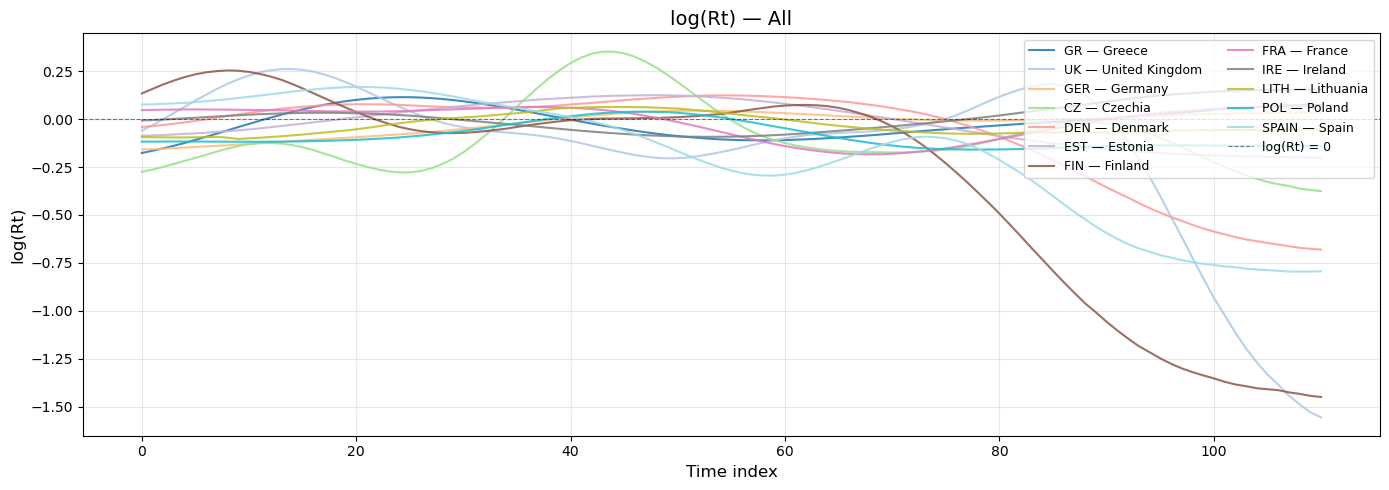

Saved: plots\11Countries.png


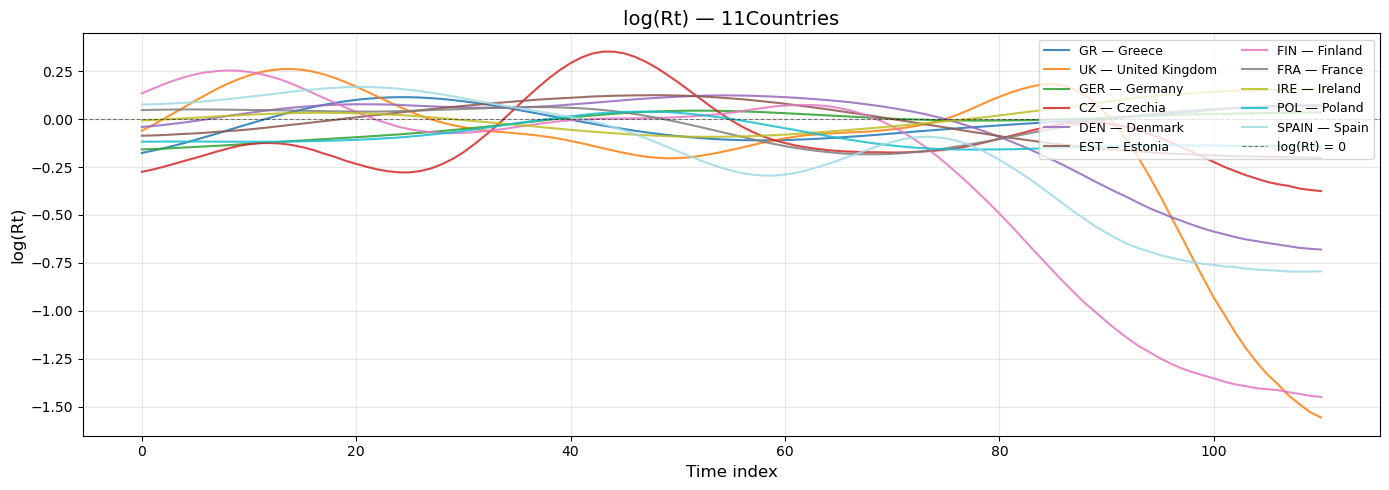

Saved: plots\Gr-Uk-Ger.png


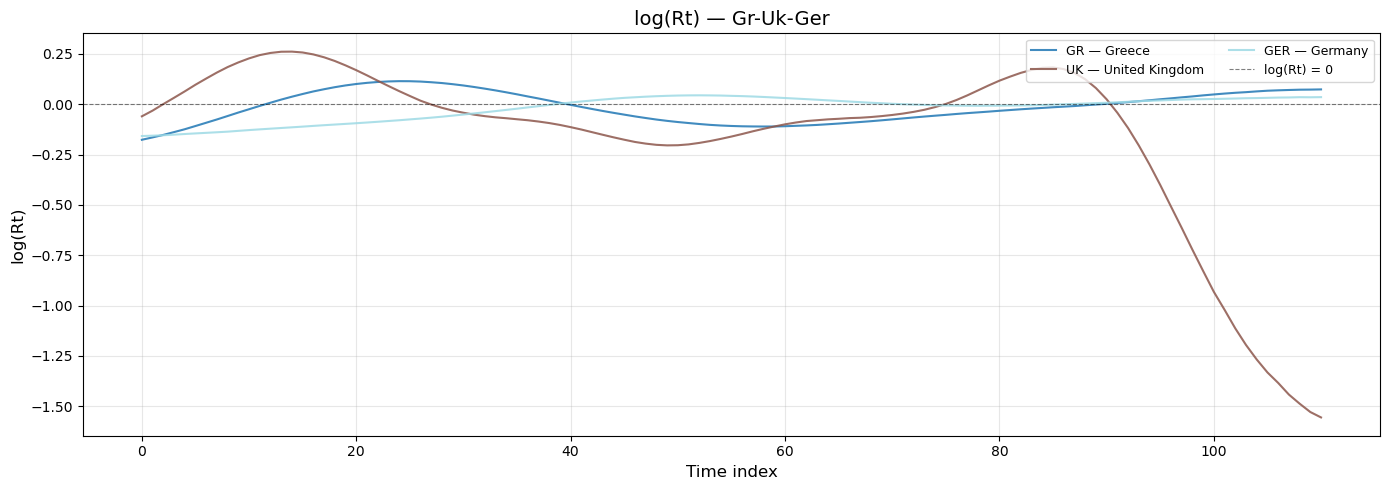

Saved: plots\Western.png


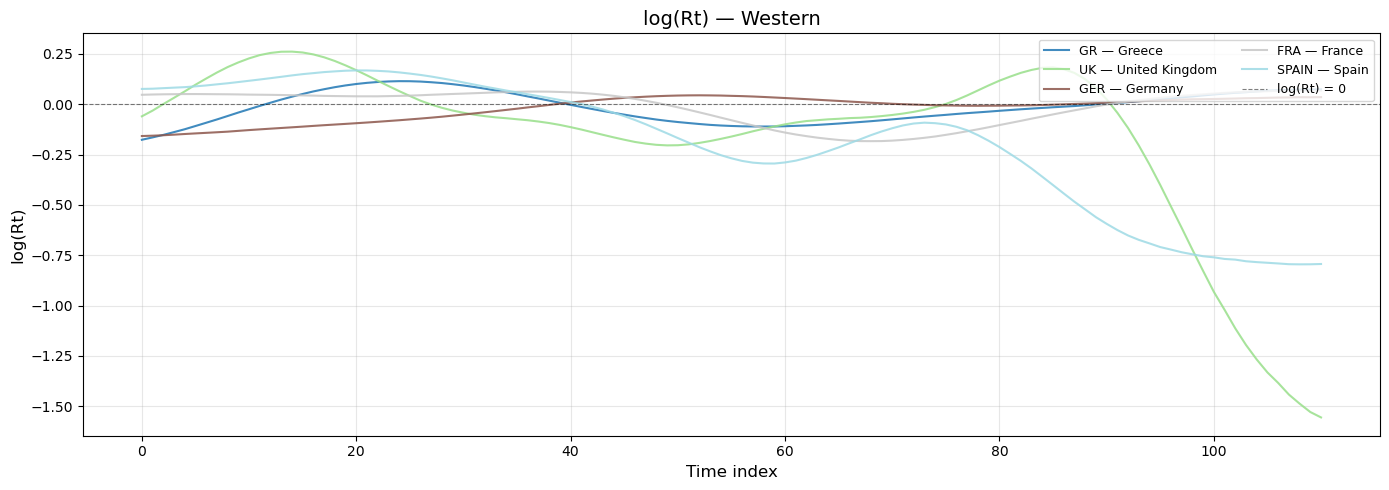

Saved: plots\Nordic.png


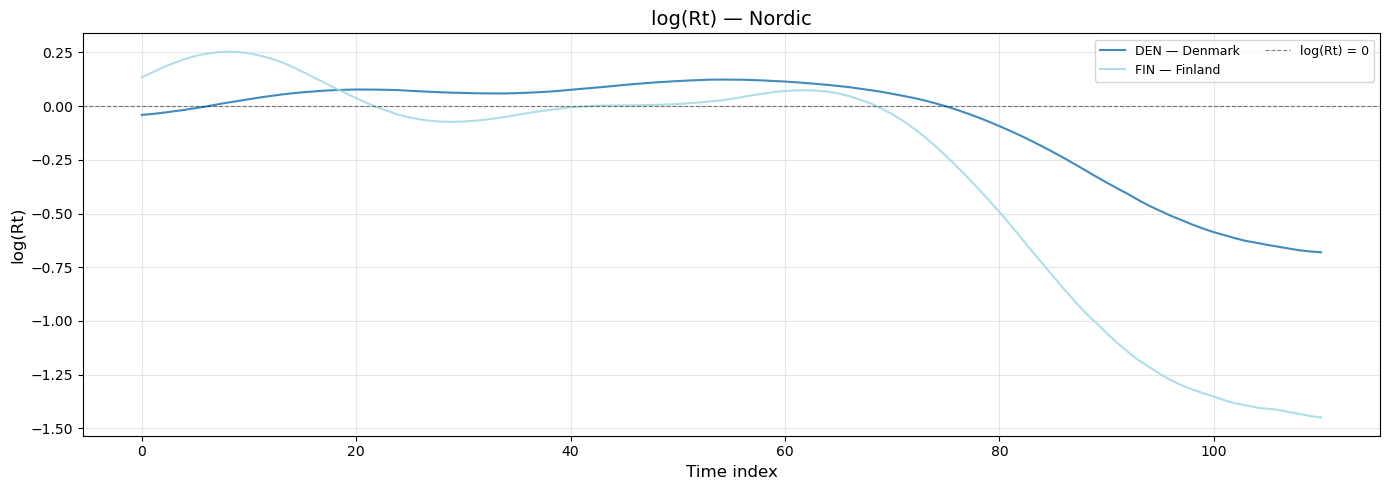

Saved: plots\Baltics.png


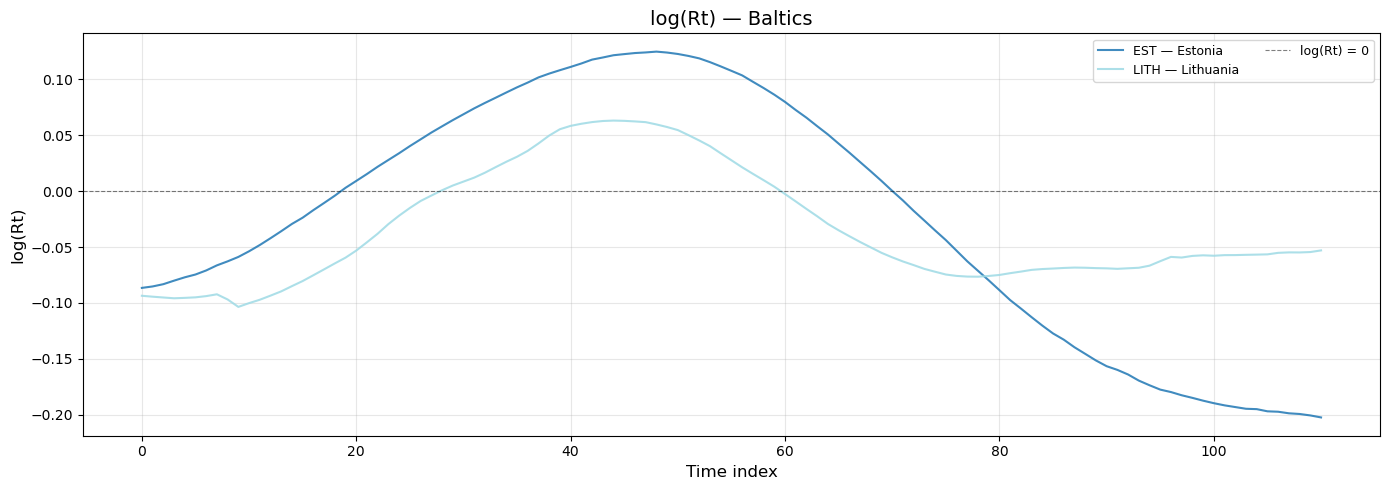

Saved: plots\Eastern.png


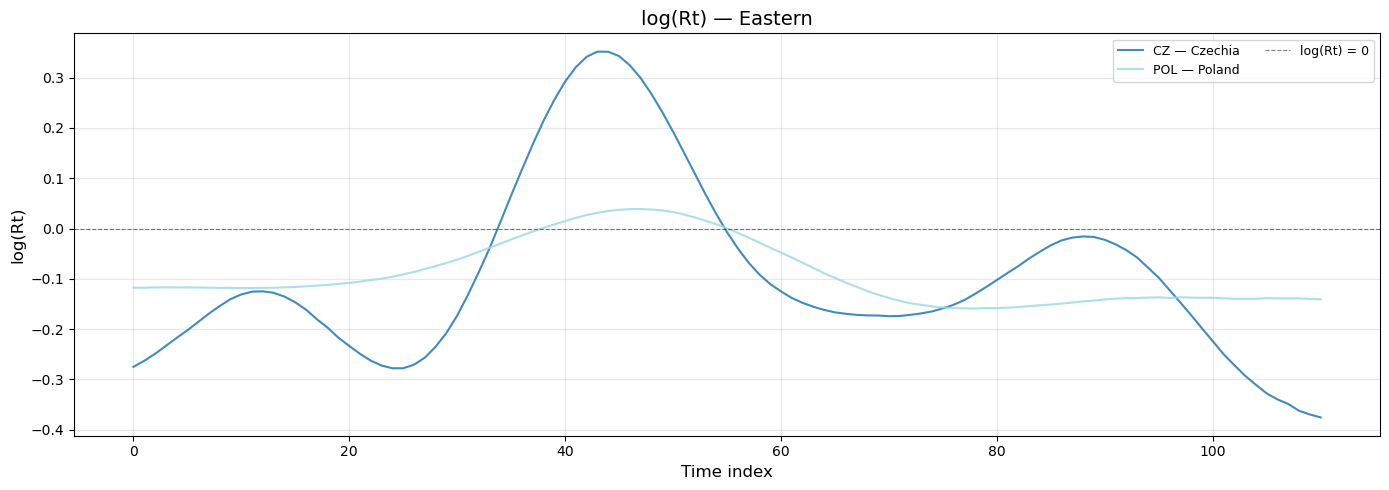

Saved: plots\Core_Eu.png


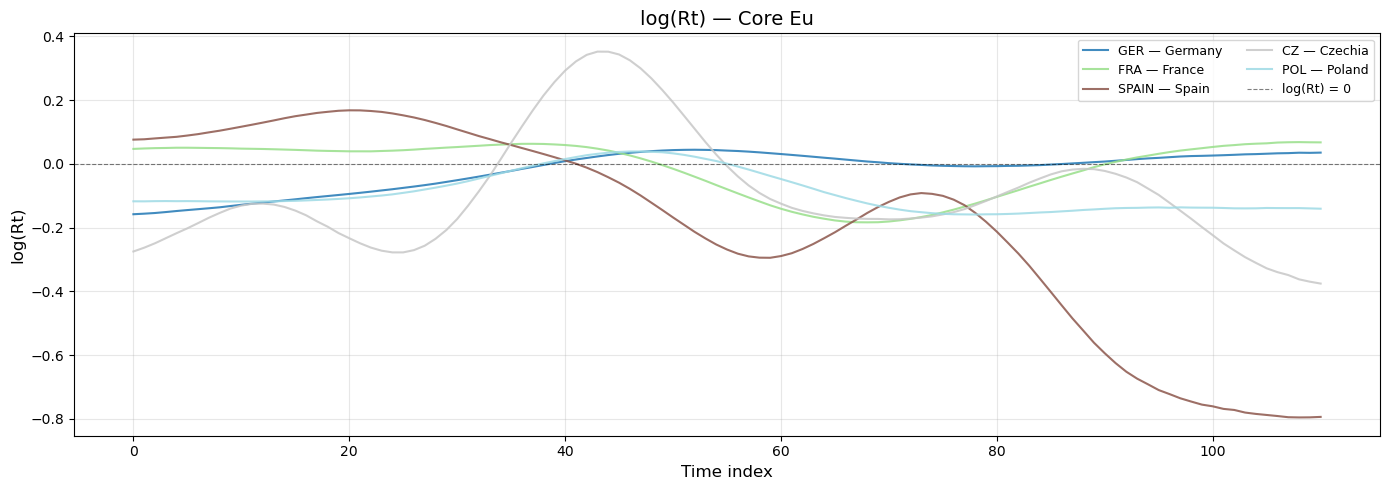

Saved: plots\Small_Open.png


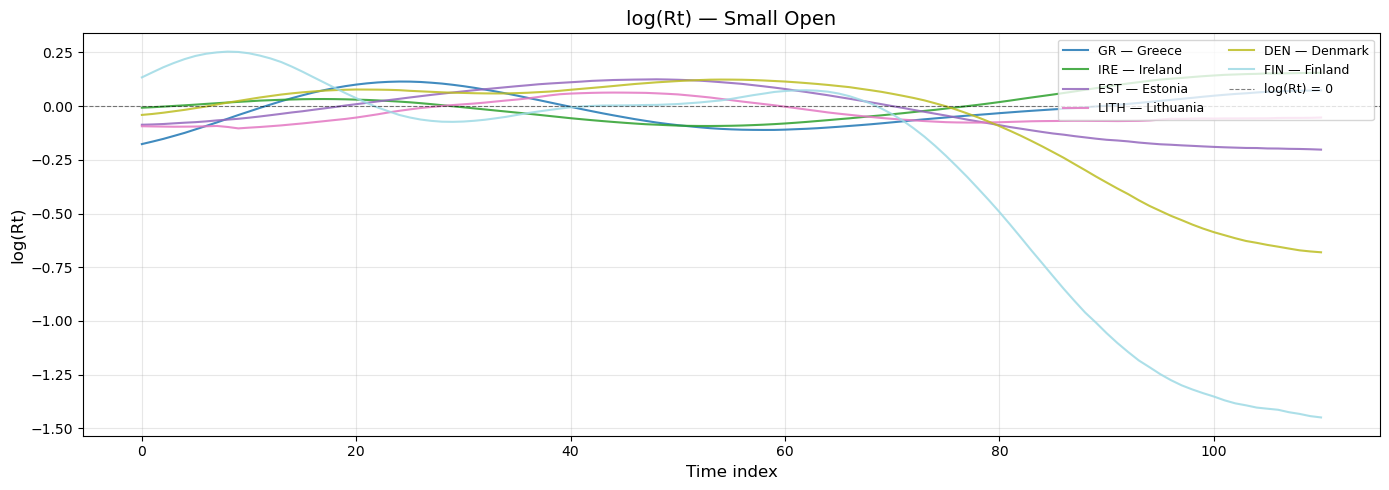

In [3]:
# All 12 countries
#plot_countries("all")

# Predefined groups by name
#plot_countries("western")
#plot_countries("baltics")
#plot_countries("nordic")
#plot_countries("eastern")
#plot_countries("core_eu")
#plot_countries("small_open")

# Any custom subset on the fly
#plot_countries(['GR', 'GER', 'UK'], title="Rt — GR vs GER vs UK")

# With data points visible
#plot_countries("baltics", show_points=True)

# Plot all groups in one go
for group_name in country_groups:
    plot_countries(group_name,save_path="plots")

## Prequential analysis per country group\nRuns the corrected prequential engine on each predefined country group and writes 5 tidy sheets per group.

In [21]:
# =========================================================
# Prequential analysis — PER COUNTRY GROUP
# (mirrors the `for group_name in country_groups` plot loop)
#
# Requires: build_dataset(), country_groups  (defined in the cells above)
#           prequential_all_simulations(), write_results_to_excel()  (engine cell)
# =========================================================
import pandas as pd
from pathlib import Path

PREQ_OUT_DIR = r"C:\Users\barbounakis\OneDrive - aueb.gr\Post Doc AUEB\BOURANIS LAMPROS - xGP_project\petros work\GP python"
Path(PREQ_OUT_DIR).mkdir(parents=True, exist_ok=True)

# choose the rolling-origin start(s) and kernels you want
train_end_starts = [63]          # e.g. [7, 28, 63] to sweep several
kernels          = ["rbf", "brownian"]
HORIZON          = 7             # step == horizon (non-overlapping windows)

preq_results_by_group = {}       # keep results in memory too

for group_name, countries_subset in country_groups.items():
    df_group = build_dataset(countries_subset)        # columns: unit_id, time, y

    # wrap the single group dataframe in the dict the engine expects
    group_sims = {f"real_{group_name}": df_group}

    for start in train_end_starts:
        for kernel in kernels:
            print(f"\n{'='*64}\nGROUP: {group_name}  |  start={start}  |  {kernel}\n{'='*64}")

            res = prequential_all_simulations(
                all_simulations=group_sims,
                kernel_type=kernel,
                scenario=None,
                train_end_start=start,
                horizon=HORIZON,
                maxiter=200,
                verbose=True,
            )

            preq_results_by_group[f"{group_name}_{start}_{kernel}"] = res

            out_name = f"{PREQ_OUT_DIR}/preq_{group_name}_start_{start}_{kernel}.xlsx"
            write_results_to_excel(res, out_name)
            print(f"Saved {out_name}")

print("\nDone. Results also kept in `preq_results_by_group`.")



GROUP: all  |  start=63  |  rbf
Simulation: real_all | kernel: rbf
  Simulation real_all | kernel=rbf | horizon=7 | origins=[63, 70, 77, 84, 91, 98]
    Model: exch_shared_rbf
    Model: exch_multiple_rbf
    Model: indep_shared_rbf
    Model: indep_multiple_rbf

TOTAL WALL TIME: 621.9s

── Joint log score | full horizon | ALL runs | per-sim mean ──
        model_name       mean     median  sd       q2_5      q97_5
 exch_multiple_rbf -44.334084 -44.334084 NaN -44.334084 -44.334084
   exch_shared_rbf -38.616103 -38.616103 NaN -38.616103 -38.616103
indep_multiple_rbf -43.093965 -43.093965 NaN -43.093965 -43.093965
  indep_shared_rbf -37.711164 -37.711164 NaN -37.711164 -37.711164

── Optimisation success across all simulations ──
        model_name  n_runs  success_pct  n_fallback  fallback_pct
 exch_multiple_rbf       6        100.0           0           0.0
   exch_shared_rbf       6        100.0           0           0.0
indep_multiple_rbf       6        100.0           0           0

## Full model (no prequential) per country group\nFits each group on all its data across the four model structures and both kernels, then extracts the fitted hyperparameters.

In [5]:
import numpy as np
import pandas as pd
import tensorflow as tf
import gpflow
import warnings
warnings.filterwarnings("ignore", category=UserWarning)


# ---------------------------------------------------------
# Brownian motion kernel
# ---------------------------------------------------------
class BrownianMotion(gpflow.kernels.Kernel):
    def __init__(self, variance=1.0):
        super().__init__()
        self.variance = gpflow.Parameter(variance, transform=gpflow.utilities.positive())

    def K(self, X, X2=None):
        if X2 is None:
            X2 = X
        t1 = X[:, 0:1]
        t2 = X2[:, 0:1]
        return self.variance * tf.minimum(t1, tf.transpose(t2))

    def K_diag(self, X):
        return self.variance * tf.reshape(X[:, 0], (-1,))


# ---------------------------------------------------------
# Heteroscedastic noise helper (kept for future use)
# ---------------------------------------------------------
class UnitVariance(gpflow.functions.Function):
    def __init__(self, n_units, active_task, init_var=0.05, lower=1e-6):
        super().__init__()
        self.active_task = active_task
        self.unit_variances = gpflow.Parameter(
            np.full(n_units, init_var, dtype=np.float64),
            transform=gpflow.utilities.positive(lower=lower),
        )

    def __call__(self, X):
        task_ids = tf.cast(tf.round(X[..., self.active_task]), tf.int32)
        variances = tf.gather(self.unit_variances, task_ids)
        return variances[..., None]


# ---------------------------------------------------------
# Kernel: Exchangeable (shared mean + shared or per-unit X kernel)
# Cov(y_i(t), y_j(t')) = k_mu(t,t') + I(i==j) * k_x(t,t')
# If exchangeable=False, k_mu is dropped → block-diagonal
# If multiple=True, each unit has its own k_x parameters
# ---------------------------------------------------------
class GPKernel(gpflow.kernels.Kernel):
    """
    Unified kernel supporting:
      - exchangeable=True  + multiple=False : shared k_mu + shared k_x per unit
      - exchangeable=True  + multiple=True  : shared k_mu + per-unit k_x
      - exchangeable=False + multiple=False : block-diagonal, shared k_x
      - exchangeable=False + multiple=True  : block-diagonal, per-unit k_x
    """
    def __init__(self, base_kernel_mu, unit_kernels_x,
                 exchangeable=True, task_dim=0, time_dim=1):
        super().__init__()
        self.base_kernel_mu = base_kernel_mu   # None if exchangeable=False
        self.unit_kernels_x = unit_kernels_x   # list of kernels (1 if shared, N if multiple)
        self.exchangeable   = exchangeable
        self.task_dim       = task_dim
        self.time_dim       = time_dim

    def K(self, X, X2=None):
        if X2 is None:
            X2 = X

        T1 = X[:,  self.time_dim:self.time_dim + 1]
        T2 = X2[:, self.time_dim:self.time_dim + 1]
        U1 = X[:,  self.task_dim]
        U2 = X2[:, self.task_dim]

        n1 = tf.shape(X)[0]
        n2 = tf.shape(X2)[0]
        K_total = tf.zeros((n1, n2), dtype=X.dtype)

        if self.exchangeable and self.base_kernel_mu is not None:
            K_total = K_total + self.base_kernel_mu.K(T1, T2)

        num_kernels = len(self.unit_kernels_x)
        for uid, k_xi in enumerate(self.unit_kernels_x):
            if num_kernels == 1:
                # shared: apply to all units (only on matching pairs)
                task_match = tf.cast(tf.equal(U1[:, None], U2[None, :]), dtype=X.dtype)
            else:
                # per-unit: apply only to unit uid
                mask_i = tf.cast(tf.equal(U1, float(uid)), dtype=X.dtype)
                mask_j = tf.cast(tf.equal(U2, float(uid)), dtype=X.dtype)
                task_match = tf.linalg.matmul(mask_i[:, None], mask_j[None, :])

            K_total = K_total + task_match * k_xi.K(T1, T2)

        return K_total

    def K_diag(self, X):
        T = X[:, self.time_dim:self.time_dim + 1]
        U = X[:, self.task_dim]

        K_diag_total = tf.zeros(tf.shape(X)[0:1], dtype=X.dtype)

        if self.exchangeable and self.base_kernel_mu is not None:
            K_diag_total = K_diag_total + self.base_kernel_mu.K_diag(T)

        num_kernels = len(self.unit_kernels_x)
        for uid, k_xi in enumerate(self.unit_kernels_x):
            if num_kernels == 1:
                K_diag_total = K_diag_total + k_xi.K_diag(T)
            else:
                mask_i = tf.cast(tf.equal(U, float(uid)), dtype=T.dtype)
                K_diag_total = K_diag_total + mask_i * k_xi.K_diag(T)

        return K_diag_total


# ---------------------------------------------------------
# Single unified fitting function
# ---------------------------------------------------------
def fit_gp(df,
           exchangeable=True,
           multiple=False,
           kernel_type="rbf",
           init_variance=1.0,
           init_lengthscale=15.0,
           init_noise=0.05,
           verbose=True):
    """
    Fit a GP model with a unified kernel.

    Parameters
    ----------
    exchangeable : bool
        If True, includes shared mean GP k_mu (exchangeable structure).
        If False, block-diagonal kernel only (independent GP structure).
    multiple : bool
        If True, each unit gets its own k_x kernel parameters.
        If False, all units share the same k_x kernel parameters.
    kernel_type : str
        'rbf' or 'brownian'.
    """

    X = df[["unit_id", "time"]].to_numpy(dtype=np.float64)
    Y = df[["y"]].to_numpy(dtype=np.float64)
    unique_units = np.sort(np.unique(X[:, 0]).astype(int))
    num_units    = len(unique_units)

    def make_kernel(variance, lengthscale):
        if kernel_type == "rbf":
            return gpflow.kernels.RBF(variance=variance, lengthscales=lengthscale)
        elif kernel_type == "brownian":
            return BrownianMotion(variance=variance)
        else:
            raise ValueError("kernel_type must be 'rbf' or 'brownian'")

    # Shared mean kernel (only used if exchangeable=True)
    base_kernel_mu = make_kernel(init_variance, init_lengthscale) if exchangeable else None

    # Unit kernels
    if multiple:
        unit_kernels_x = [make_kernel(init_variance, init_lengthscale) for _ in range(num_units)]
    else:
        unit_kernels_x = [make_kernel(init_variance, init_lengthscale)]  # single shared kernel

    kernel = GPKernel(
        base_kernel_mu=base_kernel_mu,
        unit_kernels_x=unit_kernels_x,
        exchangeable=exchangeable,
        task_dim=0,
        time_dim=1,
    )

    likelihood = gpflow.likelihoods.Gaussian(variance=init_noise)

    m = gpflow.models.GPR(data=(X, Y), kernel=kernel, likelihood=likelihood)

    opt      = gpflow.optimizers.Scipy()
    opt_logs = opt.minimize(m.training_loss, variables=m.trainable_variables)

    if verbose:
        model_label = (
            f"{'Exchangeable' if exchangeable else 'Independent'} | "
            f"{'Multiple' if multiple else 'Shared'} | "
            f"{kernel_type.upper()}"
        )
        print("=" * 60)
        print(model_label)
        print("=" * 60)
        print(f"  Optimization success : {opt_logs.success}")
        print("-" * 60)

        if exchangeable:
            kmu = base_kernel_mu
            print(f"  Shared mean variance sigma2_mu : {float(kmu.variance.numpy()):.4f}")
            if kernel_type == "rbf":
                print(f"  Shared mean lengthscale ell_mu : {float(np.asarray(kmu.lengthscales.numpy()).squeeze()):.4f}")

        print(f"  Unit kernel(s):")
        for i, k_xi in enumerate(unit_kernels_x):
            label = f"Unit {unique_units[i]}" if multiple else "Shared (all units)"
            sigma2_xi = float(k_xi.variance.numpy())
            if exchangeable:
                sigma2_mu = float(base_kernel_mu.variance.numpy())
                icc = sigma2_mu / (sigma2_mu + sigma2_xi)
                icc_str = f", ICC = {icc:.4f}"
            else:
                icc_str = ""
            if kernel_type == "rbf":
                ell_xi = float(np.asarray(k_xi.lengthscales.numpy()).squeeze())
                print(f"    {label}: sigma2_x = {sigma2_xi:.4f}, ell_x = {ell_xi:.4f}{icc_str}")
            else:
                print(f"    {label}: sigma2_x = {sigma2_xi:.4f} (Brownian){icc_str}")

        print(f"  Noise variance sigma2_eps : {float(m.likelihood.variance.numpy()):.5f}")
        print("=" * 60)

    return m

In [6]:
# =========================================================
# Full model (NO prequential) — PER COUNTRY GROUP
# Fits each group on ALL its data with the 4 model structures
# x both kernels, then extracts the fitted hyperparameters.
#
# Mirrors cell 16 but covers all four model structures
# (exchangeable/independent x shared/multiple) and saves a
# single tidy parameter table.
# =========================================================
import numpy as np
import pandas as pd
from pathlib import Path

FULL_OUT = "full_model_parameters_all_groups.xlsx"

model_specs_full = [
    ("exch_shared",   dict(exchangeable=True,  multiple=False)),
    ("exch_multiple", dict(exchangeable=True,  multiple=True)),
    ("indep_shared",  dict(exchangeable=False, multiple=False)),
    ("indep_multiple",dict(exchangeable=False, multiple=True)),
]

full_fitted   = {}   # (group, model_name, kernel) -> fitted GPR model
param_rows    = []

for group_name, countries_subset in country_groups.items():
    df_group = build_dataset(countries_subset)        # unit_id, time, y

    for model_name, flags in model_specs_full:
        for kernel in ["rbf", "brownian"]:
            print(f"\nFitting full model: {group_name} | {model_name} | {kernel}")
            m = fit_gp(
                df_group,
                kernel_type=kernel,
                init_variance=1.0,
                init_lengthscale=15.0,
                init_noise=0.05,
                verbose=False,
                **flags,
            )
            full_fitted[(group_name, model_name, kernel)] = m

            # --- extract hyperparameters (uses the engine's ExchangeableKernel) ---
            kern  = m.kernel
            noise = float(np.asarray(m.likelihood.variance.numpy()).squeeze())
            exch  = flags["exchangeable"]
            mult  = flags["multiple"]

            if exch and kern.base_kernel_mu is not None:
                sigma2_mu = float(kern.base_kernel_mu.variance.numpy())
                ls_mu = (float(np.asarray(kern.base_kernel_mu.lengthscales.numpy()).squeeze())
                         if kernel == "rbf" else np.nan)
            else:
                sigma2_mu, ls_mu = np.nan, np.nan

            for uid, kxi in enumerate(kern.unit_kernels_x):
                sigma2_x = float(kxi.variance.numpy())
                ls_x = (float(np.asarray(kxi.lengthscales.numpy()).squeeze())
                        if kernel == "rbf" else np.nan)
                if mult:
                    code = countries_subset[uid]
                    unit_label = f"{code} — {country_full_name.get(code, code)}"
                else:
                    unit_label = "shared"
                icc = (sigma2_mu / (sigma2_mu + sigma2_x)
                       if (exch and not np.isnan(sigma2_mu) and (sigma2_mu + sigma2_x) > 0)
                       else np.nan)
                param_rows.append({
                    "group": group_name,
                    "countries": ", ".join(countries_subset),
                    "model_name": model_name,
                    "kernel_type": kernel,
                    "unit": unit_label,
                    "mu_variance": sigma2_mu, "mu_lengthscale": ls_mu,
                    "x_variance": sigma2_x,   "x_lengthscale": ls_x,
                    "icc": icc, "noise_var": noise,
                })

df_full_params = pd.DataFrame(param_rows)
round_cols = ["mu_variance", "mu_lengthscale", "x_variance",
              "x_lengthscale", "icc", "noise_var"]
df_full_params[round_cols] = df_full_params[round_cols].round(4)

print("\n── Full-model fitted parameters (all groups, all model types) ──")
print(df_full_params.to_string(index=False))

with pd.ExcelWriter(FULL_OUT, engine="openpyxl") as writer:
    df_full_params.to_excel(writer, sheet_name="full_model_params", index=False)
print(f"\nSaved {FULL_OUT}")



Fitting full model: all | exch_shared | rbf

Fitting full model: all | exch_shared | brownian

Fitting full model: all | exch_multiple | rbf

Fitting full model: all | exch_multiple | brownian

Fitting full model: all | indep_shared | rbf

Fitting full model: all | indep_shared | brownian

Fitting full model: all | indep_multiple | rbf

Fitting full model: all | indep_multiple | brownian

Fitting full model: 11countries | exch_shared | rbf

Fitting full model: 11countries | exch_shared | brownian

Fitting full model: 11countries | exch_multiple | rbf

Fitting full model: 11countries | exch_multiple | brownian

Fitting full model: 11countries | indep_shared | rbf

Fitting full model: 11countries | indep_shared | brownian

Fitting full model: 11countries | indep_multiple | rbf

Fitting full model: 11countries | indep_multiple | brownian

Fitting full model: GR-UK-GER | exch_shared | rbf

Fitting full model: GR-UK-GER | exch_shared | brownian

Fitting full model: GR-UK-GER | exch_multipl

Exchangeable | Multiple | RBF
  Optimization success : True
------------------------------------------------------------
  Shared mean variance sigma2_mu : 0.0047
  Shared mean lengthscale ell_mu : 18.9973
  Unit kernel(s):
    Unit 0: sigma2_x = 0.0204, ell_x = 19.9810, ICC = 0.1885
    Unit 1: sigma2_x = 0.2965, ell_x = 12.5932, ICC = 0.0157
    Unit 2: sigma2_x = 0.0152, ell_x = 72.8478, ICC = 0.2380
    Unit 3: sigma2_x = 0.0400, ell_x = 10.7132, ICC = 0.1060
    Unit 4: sigma2_x = 0.0870, ell_x = 19.2777, ICC = 0.0517
    Unit 5: sigma2_x = 0.0032, ell_x = 17.8461, ICC = 0.5956
    Unit 6: sigma2_x = 0.3232, ell_x = 14.6662, ICC = 0.0145
    Unit 7: sigma2_x = 0.0157, ell_x = 20.4880, ICC = 0.2321
    Unit 8: sigma2_x = 0.0199, ell_x = 19.9539, ICC = 0.1926
    Unit 9: sigma2_x = 0.0023, ell_x = 17.3601, ICC = 0.6751
    Unit 10: sigma2_x = 0.0853, ell_x = 13.6459, ICC = 0.0527
  Noise variance sigma2_eps : 0.00000

Per-country ICC (share of variance that is country-specific):
cou

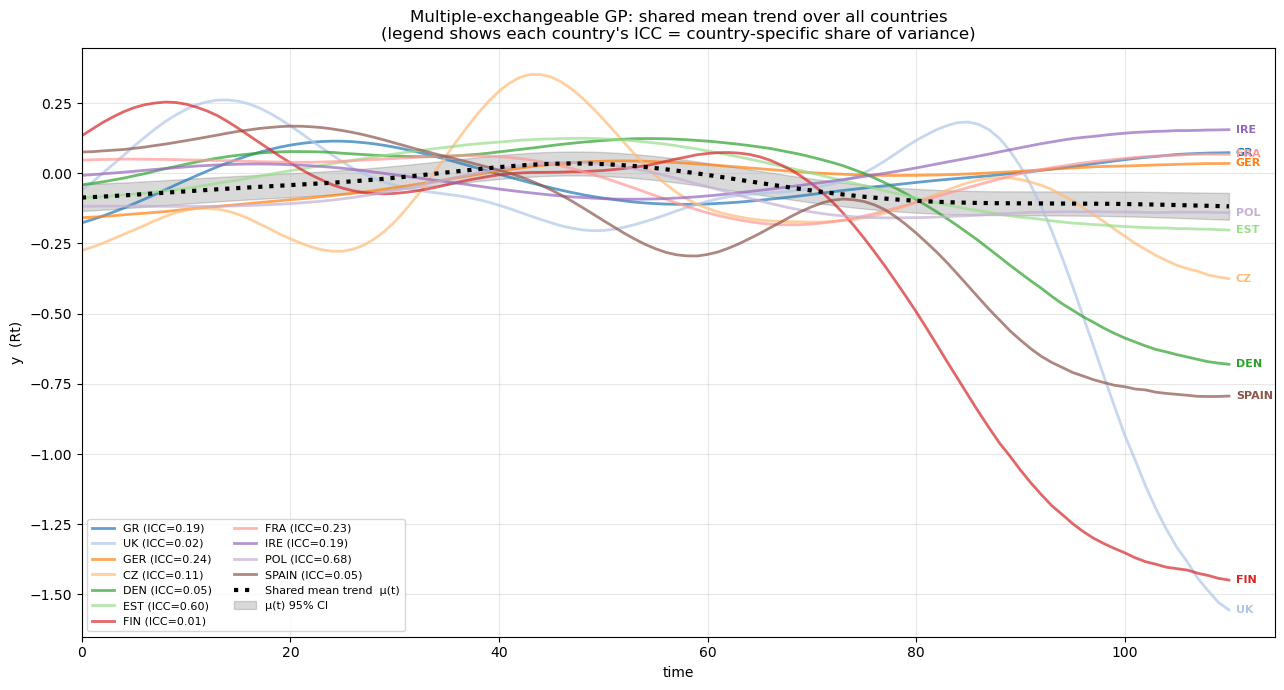


Saved plot -> multiple_exchangeable_mean_trend.png


In [19]:
# =========================================================
# Multiple-Exchangeable model on REAL data:
#   fit -> extract per-country ICC -> plot the shared mean
#   trend (mu) on top of every country's data
#
# Model:  y_i(t) = mu(t) + x_i(t) + eps
#   mu(t)  : shared exchangeable trend  (base_kernel_mu, common to all)
#   x_i(t) : country-specific deviation (per-unit kernel, "multiple")
#   ICC_i  = sigma2_x_i / (sigma2_mu + sigma2_x_i)
#
# NOTE ON THE MEAN TREND:
#   fit_gp's predict_f returns mu(t)+x_i(t) for a given unit, NOT mu alone.
#   The shared trend is recovered analytically:
#       E[mu(t*) | y] = K_mu(t*, T_all) @ K_yy^{-1} @ y
#   where K_mu uses the shared-mean kernel with NO unit masking (every
#   country informs mu), and K_yy is the full fitted training covariance.
# =========================================================
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

def _kernel_time_cov(kern, t_a, t_b):
    """Evaluate a (time-only) gpflow kernel between two 1-D time vectors."""
    Ta = np.asarray(t_a, dtype=np.float64).reshape(-1, 1)
    Tb = np.asarray(t_b, dtype=np.float64).reshape(-1, 1)
    return kern.K(Ta, Tb).numpy()

def shared_mean_posterior(model, df_train, t_star):
    """
    Posterior of the shared exchangeable trend mu(t*) given all data.
    Returns (mean, sd) at the requested test times t_star.
    Works for the GPKernel used by fit_gp (base_kernel_mu + unit_kernels_x).
    """
    kern = model.kernel
    assert getattr(kern, "base_kernel_mu", None) is not None, \
        "Model has no shared mean (need exchangeable=True)."

    X = df_train[["unit_id", "time"]].to_numpy(dtype=np.float64)
    y = df_train[["y"]].to_numpy(dtype=np.float64)
    t_train = X[:, 1]
    n = X.shape[0]

    # Full training covariance K_yy = GPKernel(X,X) + noise I   (exactly what GPR uses)
    K_yy = kern.K(X, X).numpy()
    noise = float(np.asarray(model.likelihood.variance.numpy()).squeeze())
    K_yy = K_yy + noise * np.eye(n)

    # Cross covariance between mu(t*) and every training point:
    # mu is SHARED, so no unit masking -> just the shared-mean kernel over times.
    K_mu_star = _kernel_time_cov(kern.base_kernel_mu, t_star, t_train)      # (n*, n)
    K_mu_ss   = _kernel_time_cov(kern.base_kernel_mu, t_star, t_star)       # (n*, n*)

    # Solve K_yy a = y  (Cholesky, stable)
    L = np.linalg.cholesky(K_yy + 1e-8 * np.eye(n))
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y))                     # K_yy^{-1} y
    mu_mean = (K_mu_star @ alpha).flatten()

    # Posterior variance: K_mu_ss - K_mu_star K_yy^{-1} K_mu_star^T
    v = np.linalg.solve(L, K_mu_star.T)                                     # (n, n*)
    mu_cov = K_mu_ss - v.T @ v
    mu_sd = np.sqrt(np.clip(np.diag(mu_cov), 0.0, None))
    return mu_mean, mu_sd

def extract_icc_multiple(model, countries_subset):
    """Per-country ICC for the multiple-exchangeable model."""
    kern = model.kernel
    sigma2_mu = float(kern.base_kernel_mu.variance.numpy())
    rows = []
    for uid, k_xi in enumerate(kern.unit_kernels_x):
        sigma2_x = float(k_xi.variance.numpy())
        icc = sigma2_mu / (sigma2_mu + sigma2_x) if (sigma2_mu + sigma2_x) > 0 else np.nan
        code = countries_subset[uid]
        rows.append({
            "unit_id": uid,
            "country_code": code,
            "country": country_col_mapping.get(code, code),
            "sigma2_mu": sigma2_mu,
            "sigma2_x": sigma2_x,
            "icc": icc,
        })
    return pd.DataFrame(rows)


# ---------------------------------------------------------
# RUN: fit the multiple-exchangeable model on a chosen set
# ---------------------------------------------------------
countries_subset = list(['GR', 'UK', 'GER', 'CZ', 'DEN', 'EST', 'FIN', 'FRA', 'IRE', 'POL', 'SPAIN'])     # all 12; or e.g. ['GR','GER','FRA']
df_me = build_dataset(countries_subset)

model_me = fit_gp(
    df_me,
    exchangeable=True,      # shared mean mu(t)
    multiple=True,          # per-country x_i(t)
    kernel_type="rbf",
    init_variance=1.0,
    init_lengthscale=15.0,
    init_noise=0.05,
    verbose=True,
)

# ---- ICC table ----
icc_df = extract_icc_multiple(model_me, countries_subset)
icc_df = icc_df.sort_values("icc", ascending=False).reset_index(drop=True)
print("\nPer-country ICC (share of variance that is country-specific):")
print(icc_df[["country_code", "country", "sigma2_x", "sigma2_mu", "icc"]]
      .round(4).to_string(index=False))

# ---- shared mean trend posterior ----
t_grid = np.linspace(df_me["time"].min(), df_me["time"].max(), 3000)
mu_mean, mu_sd = shared_mean_posterior(model_me, df_me, t_grid)


# =========================================================
# PLOT: all countries' data + shared exchangeable trend
# ICC shown in the legend for each country
# =========================================================
# =========================================================
# PLOT: all countries' data + shared exchangeable trend
# ICC shown in the legend; country code labelled at the end of each line
# =========================================================
fig, ax = plt.subplots(figsize=(13, 7))

cmap = plt.get_cmap("tab20")
icc_lookup = icc_df.set_index("unit_id")["icc"].to_dict()

x_max = df_me["time"].max()

for uid in sorted(df_me["unit_id"].unique()):
    d = df_me[df_me["unit_id"] == uid].sort_values("time")
    code = countries_subset[uid]
    icc = icc_lookup.get(uid, np.nan)
    color = cmap(uid % 20)

    ax.plot(d["time"], d["y"], lw=2.0, alpha=0.7, color=color,
            label=f"{code} (ICC={icc:.2f})")

    # label the country code at the end (last point) of each line
    last = d.iloc[-1]
    ax.annotate(code,
                xy=(last["time"], last["y"]),
                xytext=(5, 0), textcoords="offset points",
                va="center", ha="left",
                fontsize=8, fontweight="bold", color=color,
                clip_on=False)

# shared mean trend (dotted) + 95% band
ax.plot(t_grid, mu_mean, color="black", lw=3.0, linestyle=":",
        label="Shared mean trend  μ(t)")
ax.fill_between(t_grid, mu_mean - 1.96 * mu_sd, mu_mean + 1.96 * mu_sd,
                color="black", alpha=0.15, label="μ(t) 95% CI")

# a little right-hand margin so the end labels aren't clipped
ax.set_xlim(df_me["time"].min(), x_max + 0.04 * (x_max - df_me["time"].min()))

ax.set_xlabel("time")
ax.set_ylabel("y  (Rt)")
ax.set_title("Multiple-exchangeable GP: shared mean trend over all countries\n"
             "(legend shows each country's ICC = country-specific share of variance)")
ax.legend(ncol=2, fontsize=8, loc="best")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("multiple_exchangeable_mean_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved plot -> multiple_exchangeable_mean_trend.png")


time runs 0..110  (111 unique points)
date span 2021-12-10 .. 2022-03-30  (111 days inclusive)
dimensions OK -> 2022-03-30
Saved -> me_trend_logRt.png


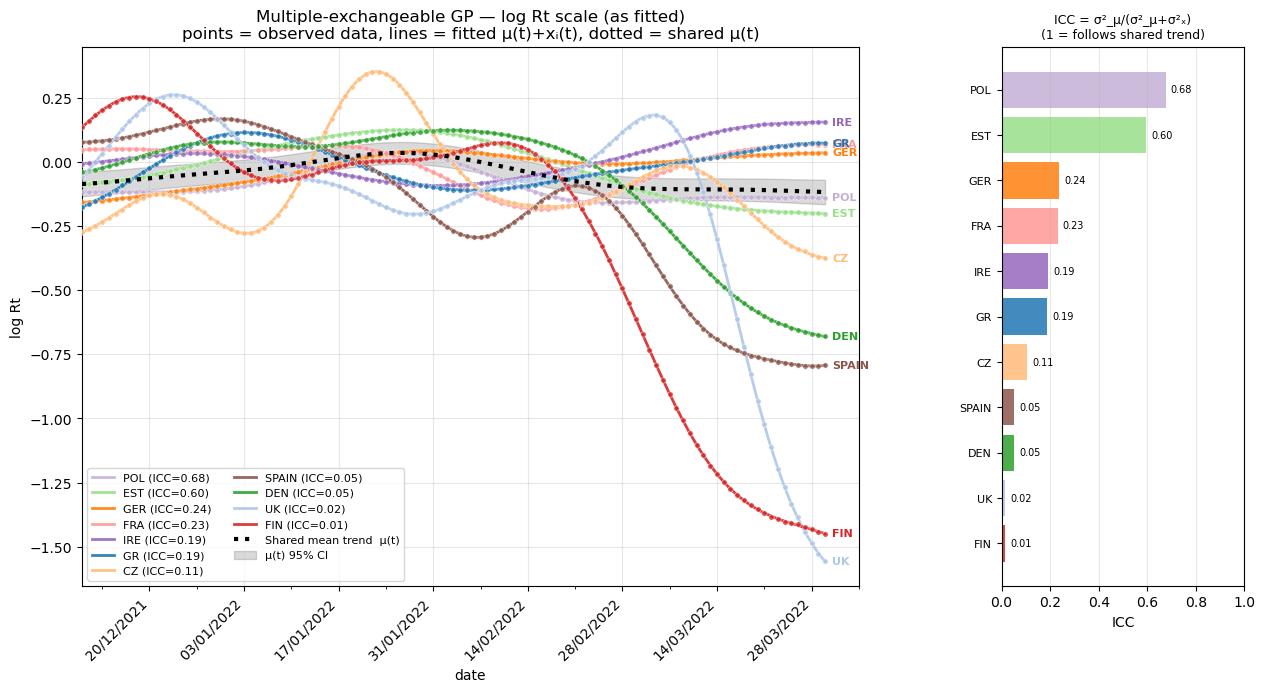

Saved -> me_trend_Rt.png


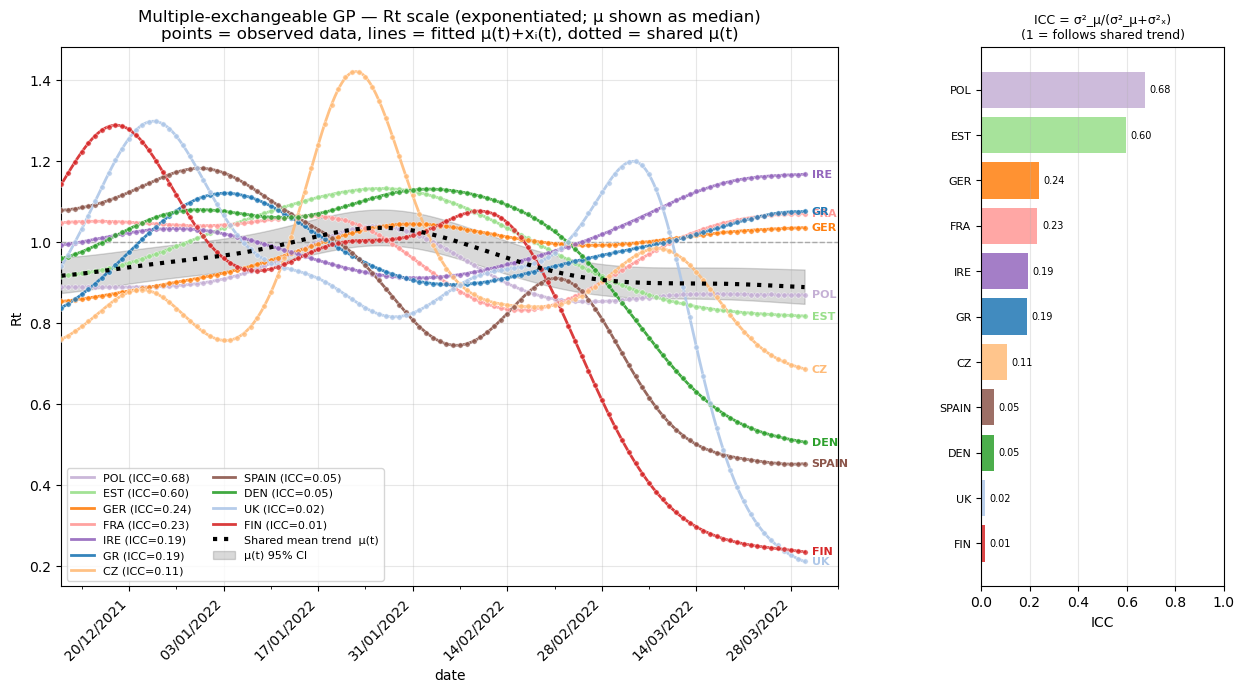

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec

# ---------------------------------------------------------
# Date axis: map time -> calendar date
# ---------------------------------------------------------
START_DATE = pd.Timestamp("2021-12-10")
END_DATE   = pd.Timestamp("2022-03-30")

t_min, t_max = df_me["time"].min(), df_me["time"].max()
n_time = df_me["time"].nunique()
expected = (END_DATE - START_DATE).days + 1          # 111

print(f"time runs {t_min}..{t_max}  ({n_time} unique points)")
print(f"date span {START_DATE.date()} .. {END_DATE.date()}  ({expected} days inclusive)")
assert n_time == expected, (
    f"DIMENSION MISMATCH: {n_time} time points but {expected} days in the date range."
)
assert (t_max - t_min) == expected - 1, (
    f"time span is {t_max - t_min}, expected {expected - 1}."
)
print("dimensions OK ->", (START_DATE + pd.Timedelta(days=int(t_max - t_min))).date())

def t_to_date(t):
    """Map the numeric time axis onto calendar dates (handles fractional t_grid)."""
    return START_DATE + pd.to_timedelta(np.asarray(t, dtype=float) - t_min, unit="D")

# ---------------------------------------------------------
# Fitted latent per country:  mu(t) + x_i(t)
# ---------------------------------------------------------
fitted = {}
for uid in sorted(df_me["unit_id"].unique()):
    Xs = np.column_stack([np.full_like(t_grid, uid, dtype=float), t_grid])
    m_i, _ = model_me.predict_f(Xs)
    fitted[uid] = m_i.numpy().ravel()

icc_sorted = icc_df.sort_values("icc", ascending=False).reset_index(drop=True)
order_uids = icc_sorted["unit_id"].tolist()
icc_lookup = icc_df.set_index("unit_id")["icc"].to_dict()

cmap  = plt.get_cmap("tab20")
color = lambda uid: cmap(uid % 20)

grid_dates = t_to_date(t_grid)


def make_plot(scale="log", fname=None):
    """scale: 'log' (log Rt, as fitted) or 'rt' (exponentiated back to Rt)."""
    tf_ = (lambda v: v) if scale == "log" else np.exp

    fig = plt.figure(figsize=(15, 7))
    gs  = GridSpec(1, 2, width_ratios=[3.2, 1.0], wspace=0.28)
    ax  = fig.add_subplot(gs[0, 0])
    axb = fig.add_subplot(gs[0, 1])

    for uid in order_uids:                       # ICC-descending -> ordered legend
        d    = df_me[df_me["unit_id"] == uid].sort_values("time")
        code = countries_subset[uid]
        c    = color(uid)

        ax.scatter(t_to_date(d["time"]), tf_(d["y"]), s=15, alpha=0.8,
                   color=c, edgecolors="white", linewidths=0.4, zorder=4)
        ax.plot(grid_dates, tf_(fitted[uid]), lw=2.0, alpha=0.9, color=c, zorder=3,
                label=f"{code} (ICC={icc_lookup[uid]:.2f})")

        ax.annotate(code, xy=(grid_dates[-1], tf_(fitted[uid])[-1]),
                    xytext=(5, 0), textcoords="offset points",
                    va="center", ha="left", fontsize=8,
                    fontweight="bold", color=c, clip_on=False)

    ax.plot(grid_dates, tf_(mu_mean), color="black", lw=3.0, linestyle=":", zorder=5,
            label="Shared mean trend  μ(t)")
    ax.fill_between(grid_dates, tf_(mu_mean - 1.96 * mu_sd), tf_(mu_mean + 1.96 * mu_sd),
                    color="black", alpha=0.15, zorder=1, label="μ(t) 95% CI")

    if scale == "rt":
        ax.axhline(1.0, color="grey", lw=1.0, ls="--", alpha=0.7, zorder=1)

    # ---- date x-axis ----
    ax.set_xlim(START_DATE, END_DATE + pd.Timedelta(days=5))   # margin for end labels
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%Y"))
    ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    ax.set_xlabel("date")
    ax.set_ylabel("log Rt" if scale == "log" else "Rt")
    ax.set_title(
        "Multiple-exchangeable GP — "
        + ("log Rt scale (as fitted)" if scale == "log"
           else "Rt scale (exponentiated; μ shown as median)")
        + "\npoints = observed data, lines = fitted μ(t)+xᵢ(t), dotted = shared μ(t)"
    )
    ax.legend(ncol=2, fontsize=8, loc="best")
    ax.grid(alpha=0.3)

    # ---- ICC barplot, descending ----
    codes = [countries_subset[u] for u in order_uids]
    iccs  = [icc_lookup[u] for u in order_uids]
    ypos  = np.arange(len(order_uids))
    axb.barh(ypos, iccs, color=[color(u) for u in order_uids], alpha=0.85)
    axb.set_yticks(ypos); axb.set_yticklabels(codes, fontsize=8)
    axb.invert_yaxis(); axb.set_xlim(0, 1)
    axb.set_xlabel("ICC")
    axb.set_title("ICC = σ²_μ/(σ²_μ+σ²ₓ)\n(1 = follows shared trend)", fontsize=9)
    axb.grid(axis="x", alpha=0.3)
    for y, v in zip(ypos, iccs):
        axb.text(min(v + 0.02, 0.98), y, f"{v:.2f}", va="center", fontsize=7)

    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        print(f"Saved -> {fname}")
    plt.show()


make_plot("log", "me_trend_logRt.png")
make_plot("rt",  "me_trend_Rt.png")

CREDIBLE-INTERVAL DIAGNOSTIC
fitted noise variance sigma2_eps = 1e-06   (sd = 0.001)
data range (log Rt)              = 1.9072
observations per country         = 111

country    resid sd  fit sd mean  fit sd max   CI width  % of range
------------------------------------------------------------------------------
GR          0.00029      0.00032     0.00074    0.00127       0.07%
UK          0.00114      0.00041     0.00089    0.00160       0.08%
GER         0.00032      0.00031     0.00068    0.00121       0.06%
CZ          0.00084      0.00042     0.00088    0.00165       0.09%
DEN         0.00058      0.00034     0.00078    0.00132       0.07%
EST         0.00044      0.00032     0.00072    0.00127       0.07%
FIN         0.00108      0.00038     0.00086    0.00151       0.08%
FRA         0.00042      0.00032     0.00073    0.00125       0.07%
IRE         0.00034      0.00032     0.00074    0.00127       0.07%
POL         0.00051      0.00032     0.00071    0.00127       0.07%
SPAIN 

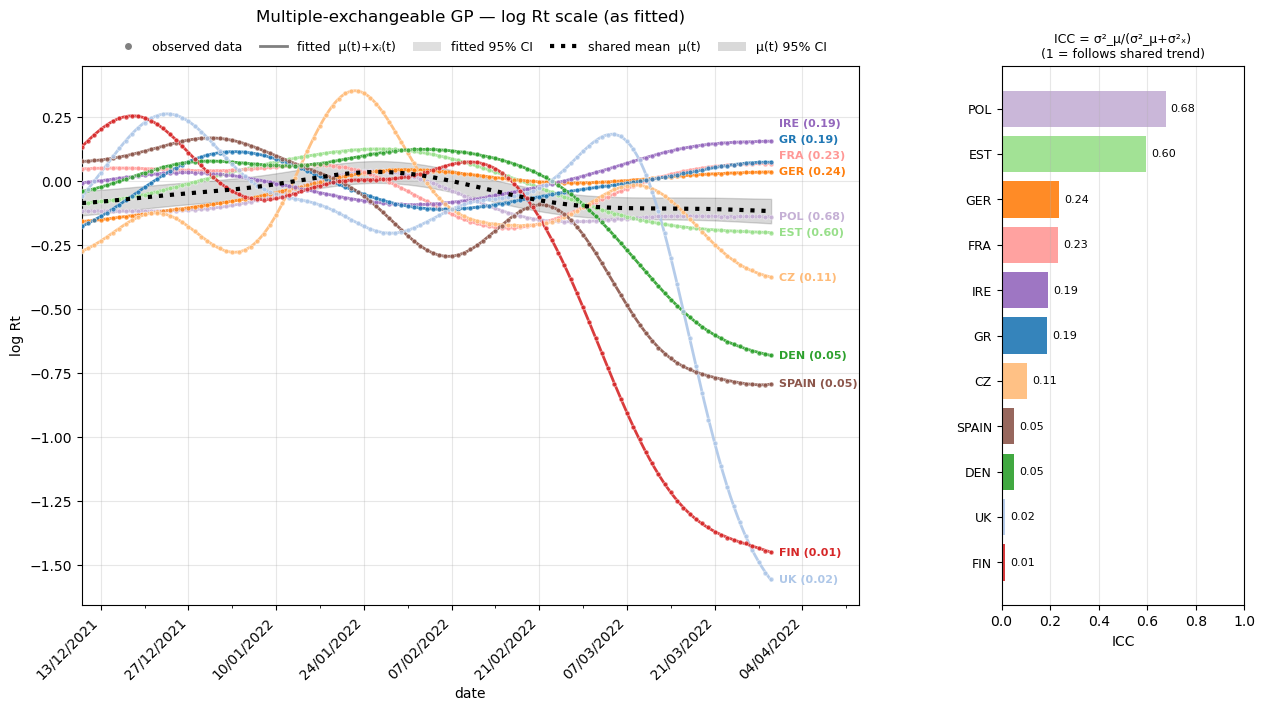

Saved -> me_trend_Rt.png


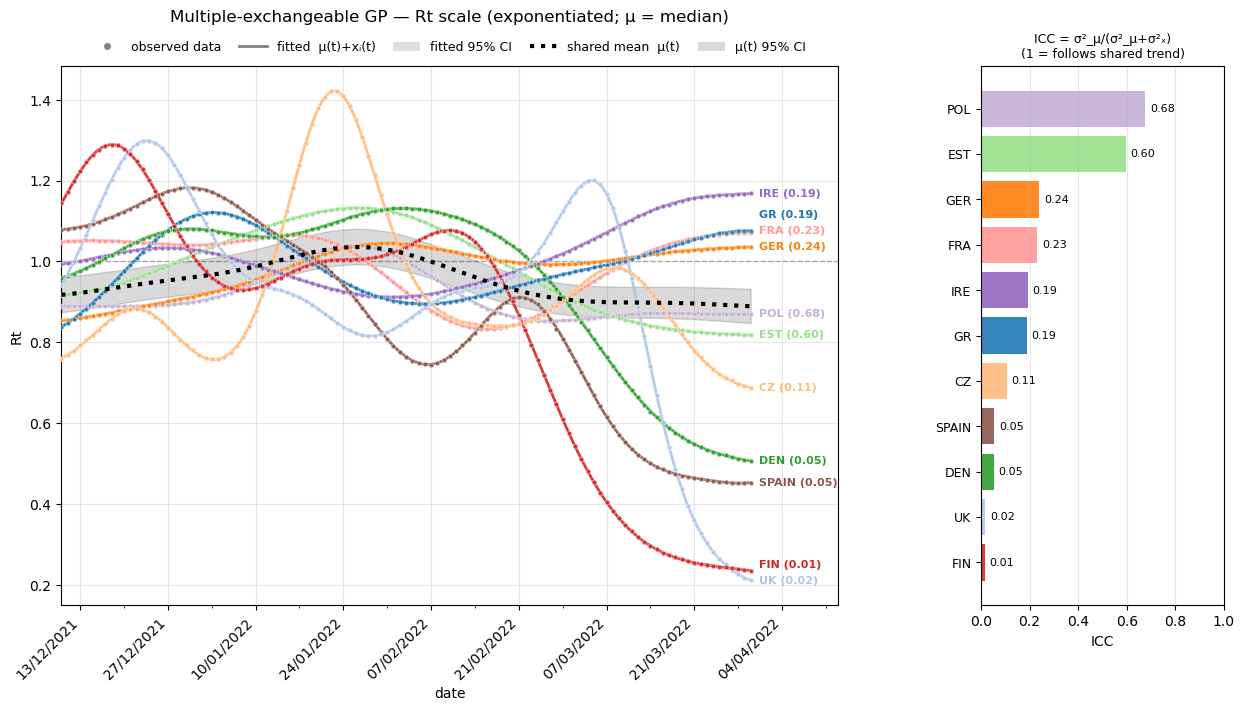

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# =========================================================
# 0. DIAGNOSTIC — why are the credible intervals so narrow?
# =========================================================
noise_var  = float(np.asarray(model_me.likelihood.variance.numpy()).squeeze())
data_range = float(df_me["y"].max() - df_me["y"].min())

print("=" * 78)
print("CREDIBLE-INTERVAL DIAGNOSTIC")
print("=" * 78)
print(f"fitted noise variance sigma2_eps = {noise_var:.6g}   (sd = {np.sqrt(noise_var):.6g})")
print(f"data range (log Rt)              = {data_range:.4f}")
print(f"observations per country         = {df_me.groupby('unit_id').size().iloc[0]}")
print()
print(f"{'country':8s} {'resid sd':>10s} {'fit sd mean':>12s} {'fit sd max':>11s} "
      f"{'CI width':>10s} {'% of range':>11s}")
print("-" * 78)

diag = {}
for uid in sorted(df_me["unit_id"].unique()):
    d = df_me[df_me["unit_id"] == uid].sort_values("time")
    Xd = d[["unit_id", "time"]].to_numpy(dtype=np.float64)
    m_d, v_d = model_me.predict_f(Xd)
    resid  = d["y"].to_numpy() - m_d.numpy().ravel()
    sd_d   = np.sqrt(np.clip(v_d.numpy().ravel(), 0.0, None))
    ci_w   = 2 * 1.96 * sd_d.mean()
    diag[uid] = (resid.std(), sd_d.mean(), sd_d.max(), ci_w)
    print(f"{countries_subset[uid]:8s} {resid.std():10.5f} {sd_d.mean():12.5f} "
          f"{sd_d.max():11.5f} {ci_w:10.5f} {100*ci_w/data_range:10.2f}%")
print("-" * 78)
print("If noise sd ~ 0 and resid sd ~ 0 -> the GP INTERPOLATES the data:")
print("  with 111 daily points and lengthscale >> 1 day, the latent is pinned")
print("  down everywhere, so the fitted CI is legitimately near-zero.")
print("=" * 78, "\n")

# =========================================================
# 1. Date axis + dimension check
# =========================================================
START_DATE = pd.Timestamp("2021-12-10")
END_DATE   = pd.Timestamp("2022-03-30")

t_min, t_max = df_me["time"].min(), df_me["time"].max()
n_time   = df_me["time"].nunique()
expected = (END_DATE - START_DATE).days + 1          # 111

print(f"time {t_min}..{t_max} ({n_time} pts) | {START_DATE.date()}..{END_DATE.date()} ({expected} days)")
assert n_time == expected, f"DIMENSION MISMATCH: {n_time} time points vs {expected} days."
assert (t_max - t_min) == expected - 1, f"time span {t_max - t_min}, expected {expected - 1}."
print("dimensions OK\n")

def t_to_date(t):
    return START_DATE + pd.to_timedelta(np.asarray(t, dtype=float) - t_min, unit="D")

grid_dates = t_to_date(t_grid)

# =========================================================
# 2. Fitted latent per country: mu(t) + x_i(t), with sd
# =========================================================
fitted, fitted_sd = {}, {}
for uid in sorted(df_me["unit_id"].unique()):
    Xs = np.column_stack([np.full_like(t_grid, uid, dtype=float), t_grid])
    m_i, v_i = model_me.predict_f(Xs)
    fitted[uid]    = m_i.numpy().ravel()
    fitted_sd[uid] = np.sqrt(np.clip(v_i.numpy().ravel(), 0.0, None))

# =========================================================
# 3. ICC-descending order (drives barplot + colours)
# =========================================================
icc_sorted = icc_df.sort_values("icc", ascending=False).reset_index(drop=True)
order_uids = icc_sorted["unit_id"].tolist()
icc_lookup = icc_df.set_index("unit_id")["icc"].to_dict()

cmap  = plt.get_cmap("tab20")
color = lambda uid: cmap(uid % 20)

# =========================================================
# 4. Plot
# =========================================================
def make_plot(scale="log", show_ci=True, ci_alpha=0.25, fname=None):
    """scale: 'log' (as fitted) or 'rt' (exponentiated)."""
    tf_ = (lambda v: v) if scale == "log" else np.exp

    fig = plt.figure(figsize=(15, 7))
    gs  = GridSpec(1, 2, width_ratios=[3.2, 1.0], wspace=0.28)
    ax  = fig.add_subplot(gs[0, 0])
    axb = fig.add_subplot(gs[0, 1])

    for uid in order_uids:
        d = df_me[df_me["unit_id"] == uid].sort_values("time")
        c = color(uid)

        if show_ci:
            lo = tf_(fitted[uid] - 1.96 * fitted_sd[uid])
            hi = tf_(fitted[uid] + 1.96 * fitted_sd[uid])
            ax.fill_between(grid_dates, lo, hi, color=c, alpha=ci_alpha, lw=0, zorder=1)

        ax.plot(grid_dates, tf_(fitted[uid]), lw=2.0, alpha=0.9, color=c, zorder=3)
        ax.scatter(t_to_date(d["time"]), tf_(d["y"]), s=12.5, alpha=0.8,
                   color=c, edgecolors="white", linewidths=0.4, zorder=4)

    ax.plot(grid_dates, tf_(mu_mean), color="black", lw=3.0, ls=":", zorder=6)
    ax.fill_between(grid_dates, tf_(mu_mean - 1.96 * mu_sd), tf_(mu_mean + 1.96 * mu_sd),
                    color="black", alpha=0.15, zorder=2)

    if scale == "rt":
        ax.axhline(1.0, color="grey", lw=1.0, ls="--", alpha=0.7, zorder=1)

    # ---- end-of-line labels, de-collided ----
    ends = sorted([(float(tf_(fitted[u])[-1]), u) for u in order_uids])
    y0, y1 = ax.get_ylim()
    gap, placed = 0.030 * (y1 - y0), []
    for yv, u in ends:
        if placed and yv - placed[-1][0] < gap:
            yv = placed[-1][0] + gap
        placed.append((yv, u))
    for yv, u in placed:
        ax.annotate(f"{countries_subset[u]} ({icc_lookup[u]:.2f})",
                    xy=(grid_dates[-1], yv), xytext=(6, 0),
                    textcoords="offset points", va="center", ha="left",
                    fontsize=8, fontweight="bold", color=color(u), clip_on=False)

    # ---- date axis ----
    ax.set_xlim(START_DATE, END_DATE + pd.Timedelta(days=14))   # room for end labels
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%Y"))
    ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

    ax.set_xlabel("date")
    ax.set_ylabel("log Rt" if scale == "log" else "Rt")
    ax.set_title("Multiple-exchangeable GP — "
                 + ("log Rt scale (as fitted)" if scale == "log"
                    else "Rt scale (exponentiated; μ = median)"),
                 pad=32)

    ax.grid(alpha=0.3)

    # ---- single style key, OUTSIDE the axes (horizontal strip) ----
    style_key = [
        Line2D([0], [0], marker="o", linestyle="none", markerfacecolor="grey",
               markeredgecolor="white", markersize=6, label="observed data"),
        Line2D([0], [0], color="grey", lw=2, label="fitted  μ(t)+xᵢ(t)"),
        Patch(facecolor="grey", alpha=ci_alpha, label="fitted 95% CI"),
        Line2D([0], [0], color="black", lw=3, ls=":", label="shared mean  μ(t)"),
        Patch(facecolor="black", alpha=0.15, label="μ(t) 95% CI"),
    ]
    ax.legend(handles=style_key, loc="lower center", bbox_to_anchor=(0.5, 1.002),
              ncol=5, frameon=False, fontsize=9, handlelength=2.2,
              columnspacing=1.4)

    # ---- ICC barplot (now the sole country/ICC key) ----
    codes = [countries_subset[u] for u in order_uids]
    iccs  = [icc_lookup[u] for u in order_uids]
    ypos  = np.arange(len(order_uids))
    axb.barh(ypos, iccs, color=[color(u) for u in order_uids], alpha=0.9)
    axb.set_yticks(ypos); axb.set_yticklabels(codes, fontsize=9)
    axb.invert_yaxis(); axb.set_xlim(0, 1)
    axb.set_xlabel("ICC")
    axb.set_title("ICC = σ²_μ/(σ²_μ+σ²ₓ)\n(1 = follows shared trend)", fontsize=9)
    axb.grid(axis="x", alpha=0.3)
    for y, v in zip(ypos, iccs):
        axb.text(min(v + 0.02, 0.98), y, f"{v:.2f}", va="center", fontsize=8)

    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=150, bbox_inches="tight")
        print(f"Saved -> {fname}")
    plt.show()


make_plot("log", show_ci=True, fname="me_trend_logRt.png")
make_plot("rt",  show_ci=True, fname="me_trend_Rt.png")

In [24]:
####Fix the wrong ICC

import glob, os
import numpy as np
import pandas as pd

SHEET = "model_parameters"

FOLDER = r"C:\Users\barbounakis\OneDrive - aueb.gr\Post Doc AUEB\BOURANIS LAMPROS - xGP_project\petros work\GP python\results with correctedcalculation of ICC"

def fix_icc_inplace(path):
    xls = pd.read_excel(path, sheet_name=None)          # all sheets
    if SHEET not in xls or not {"sigma2_mu", "sigma2_x"}.issubset(xls[SHEET].columns):
        print(f"  skip: {os.path.basename(path)}")
        return False

    mp = xls[SHEET].copy()
    denom = mp["sigma2_mu"] + mp["sigma2_x"]
    icc = np.where(denom > 0, mp["sigma2_mu"] / denom, np.nan)   # correct ICC = shared share
    icc = np.where(mp["sigma2_mu"].isna(), np.nan, icc)          # NaN for independent models
    mp["icc"] = icc
    xls[SHEET] = mp

    with pd.ExcelWriter(path, engine="openpyxl") as xl:          # overwrite, all sheets
        for name, df in xls.items():
            df.to_excel(xl, sheet_name=name[:31], index=False)
    print(f"  fixed: {os.path.basename(path)}")
    return True

files = sorted(glob.glob(os.path.join(FOLDER, "**", "*.xlsx"), recursive=True))
print(f"Found {len(files)} file(s) in:\n  {FOLDER}\n")
n = sum(fix_icc_inplace(f) for f in files)
print(f"\nDone. {n} file(s) updated.")

Found 0 file(s) in:
  C:\Users\barbounakis\OneDrive - aueb.gr\Post Doc AUEB\BOURANIS LAMPROS - xGP_project\petros work\GP python\results with correctedcalculation of ICC


Done. 0 file(s) updated.


In [25]:
0.1/1.1

0.09090909090909091